# Impact of Rates Revaluations Bracket Creep on Business Life Expectancy in London’s Four Boroughs: Descriptive Analysis

All raw data, including the 2017 and 2023 datasets, LSOA shapefiles, and related economic variables, are available in the GitHub repository: [business_rate_LN/data_source](https://github.com/JialeiGuo1108/business_rate_LN).

## Time Range
- 2017(First period): 2016-06-30, 2016-12-31, 2017-06-30, 2017-12-31, 2018-06-30, 2019-06-30
- 2023(Second period): 2022-06-30, 2022-12-31, 2023-06-30, 2023-12-31, 2024-06-30, 2025-06-30

## Framework
- 2017 Cycle Analysis:
  - Descriptive Analysis: Baseline characteristics and distributional patterns across the four London boroughs
  - Dynamic Bunching: Evidence of bracket creep phenomena through rateable value clustering around the £15,000 threshold
  - Business Strategy: Firm responses to tax burden changes, tracking strategic evolution (acceptance, successful appeals, space reduction, mixed approaches)
    

- Comparative 2017-2023 Analysis:
  - Survival Analysis: Primary analysis using 2017 data to establish survival-bracket creep relationships, with 2023 as replication study to test robustness across different economic contexts
  - Panel Regression and Predictive Modelling for 2026 Revaluation: Econometric modeling using both cycles to forecast business outcomes under future revaluation scenarios

In [52]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkb

from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Import the 2017 and 2023 Business Dataset

In [53]:
citylondon_17 = pd.read_csv('data_source/period-2010-to-2017-E09000001-city of london.csv')
camden_17 = pd.read_csv('data_source/period-2010-to-2017-E09000007-camden.csv')
hackney_17 = pd.read_csv('data_source/period-2010-to-2017-E09000012-hackney.csv')
westminster_17 = pd.read_csv('data_source/period-2010-to-2017-E09000033-westminster.csv')

In [54]:
# Cleaning
citylondon_17N = citylondon_17[citylondon_17['rateable_value'] > 0]  # Remove outliers
citylondon_17N = citylondon_17N.dropna(subset=['rateable_value'])

camden_17N = camden_17[camden_17['rateable_value'] > 0]
camden_17N = camden_17N.dropna(subset=['rateable_value'])

hackney_17N = hackney_17[hackney_17['rateable_value'] > 0]
hackney_17N = hackney_17N.dropna(subset=['rateable_value'])

westminster_17N = westminster_17[westminster_17['rateable_value'] > 0]
westminster_17N = westminster_17N.dropna(subset=['rateable_value'])

# Convert WKB geometry to Shapely objects
citylondon_17N['geom'] = citylondon_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
camden_17N['geom'] = camden_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
hackney_17N['geom'] = hackney_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
westminster_17N['geom'] = westminster_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))

In [55]:
# Import the data
citylondon_23 = pd.read_csv('data_source/period-2017-to-2023-E09000001-city of london.csv')
camden_23 = pd.read_csv('data_source/period-2017-to-2023-E09000007-camden.csv')
hackney_23 = pd.read_csv('data_source/period-2017-to-2023-E09000012-hackney.csv')
westminster_23 = pd.read_csv('data_source/period-2017-to-2023-E09000033-westminster.csv')

# Cleaning
citylondon_23N = citylondon_23[citylondon_23['rateable_value'] > 0]  # Remove outliers
citylondon_23N = citylondon_23N.dropna(subset=['rateable_value'])

camden_23N = camden_23[camden_23['rateable_value'] > 0]
camden_23N = camden_23N.dropna(subset=['rateable_value'])

hackney_23N = hackney_23[hackney_23['rateable_value'] > 0]
hackney_23N = hackney_23N.dropna(subset=['rateable_value'])

westminster_23N = westminster_23[westminster_23['rateable_value'] > 0]
westminster_23N = westminster_23N.dropna(subset=['rateable_value'])

# Convert WKB geometry to Shapely objects
citylondon_23N['geom'] = citylondon_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
camden_23N['geom'] = camden_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
hackney_23N['geom'] = hackney_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
westminster_23N['geom'] = westminster_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))

In [56]:
# Lsoa shp
citylondon_lsoa = gpd.read_file('data_source/LB_shp/City of London.shp')
camden_lsoa = gpd.read_file('data_source/LB_shp/Camden.shp')
hackney_lsoa = gpd.read_file('data_source/LB_shp/Hackney.shp')
westminster_lsoa = gpd.read_file('data_source/LB_shp/Westminster.shp')

# Merge the data from the four regions

In [57]:
# Merge into 2017 overall data
citylondon_17N['borough'] = 'City of London'
camden_17N['borough'] = 'Camden'  
hackney_17N['borough'] = 'Hackney'
westminster_17N['borough'] = 'Westminster'

data_2017 = pd.concat([citylondon_17N, camden_17N, hackney_17N, westminster_17N], 
                      ignore_index=True)

In [58]:
#2023
citylondon_23N['borough'] = 'City of London'
camden_23N['borough'] = 'Camden'  
hackney_23N['borough'] = 'Hackney'
westminster_23N['borough'] = 'Westminster'

data_2023 = pd.concat([citylondon_23N, camden_23N, hackney_23N, westminster_23N], 
                      ignore_index=True)



## Add the timepoint
- 2017(First period): 2016-06-30, 2016-12-31, 2017-06-30, 2017-12-31, 2018-06-30, 2019-06-30
- 2023(Second period): 2022-06-30, 2022-12-31, 2023-06-30, 2023-12-31, 2024-06-30, 2025-06-30

In [59]:
def add_timepoint_field(df, revaluation_year='2017'):
    """
    Add timepoint field based on series and epoch column combinations
    """
    
    if revaluation_year == '2017':
        conditions = [
            (df['series'] == 2010) & (df['epoch'] == 21),
            (df['series'] == 2010) & (df['epoch'] == 23),
            (df['series'] == 2017) & (df['epoch'] == 2),
            (df['series'] == 2017) & (df['epoch'] == 4),
            (df['series'] == 2017) & (df['epoch'] == 7),
            (df['series'] == 2017) & (df['epoch'] == 13)
        ]
    elif revaluation_year == '2023':
        conditions = [
            (df['series'] == 2017) & (df['epoch'] == 32),
            (df['series'] == 2017) & (df['epoch'] == 34),
            (df['series'] == 2023) & (df['epoch'] == 2),
            (df['series'] == 2023) & (df['epoch'] == 5),
            (df['series'] == 2023) & (df['epoch'] == 8),
            (df['series'] == 2023) & (df['epoch'] == 15)
        ]
    else:
        print(f"Unrecognized revaluation_year: {revaluation_year}")
        return df
    
    timepoint_labels = ['-12', '-6', '0', '+6', '+12', '+24']
    df['timepoint'] = np.select(conditions, timepoint_labels, default='other')
    df = df[df['timepoint'] != 'other']# Extract the useful data
    
    return df

In [61]:
data_2017.columns = data_2017.columns.str.lower()
data_2023.columns = data_2023.columns.str.lower()

data_2017 = add_timepoint_field(data_2017, '2017')
data_2023 = add_timepoint_field(data_2023, '2023')

# Convert the values of the string column to lowercase
categorical_columns = ['category_group', 'category_subgroup', 'primary_description', 
                      'occupation_state', 'account_name', 'billing_authority_name']

for col in categorical_columns:
    if col in data_2017.columns:
        data_2017[col] = data_2017[col].str.lower()
    if col in data_2023.columns:
        data_2023[col] = data_2023[col].str.lower()


In [62]:
data_2017.columns

Index(['filter_period', 'billing_authority_name', 'geocode', 'uarn',
       'billing_reference', 'account_name', 'account_start_date',
       'searchable_address', 'postcode_id', 'geometry', 'occupation_state',
       'occupation_date', 'category_id', 'primary_description',
       'category_subgroup', 'category_group', 'rates_payable',
       'rateable_value', 'total_floor_area', 'unit_of_measure', 'from_date',
       'record_date', 'series', 'epoch', 'geom', 'borough', 'timepoint'],
      dtype='object')

# Sensitive Analysis

In [63]:
def determine_optimal_window(df, threshold=15000, window_range=[500, 1000, 1500, 2000, 2500, 3000]):
    """
    Determine optimal window size through sensitivity analysis
    """
    results = {}
    
    for window in window_range:
        # Calculate bunching ratio for each window
        lower_bound = threshold - window
        upper_bound = threshold + window
        
        # Count businesses in window ranges
        below_threshold = df[(df['rateable_value'] >= lower_bound) & 
                           (df['rateable_value'] < threshold)].shape[0]
        above_threshold = df[(df['rateable_value'] >= threshold) & 
                           (df['rateable_value'] <= upper_bound)].shape[0]
        
        # Calculate bunching ratio
        ratio = below_threshold / above_threshold if above_threshold > 0 else 0
        
        results[window] = {
            'bunching_ratio': ratio,
            'businesses_below': below_threshold,
            'businesses_above': above_threshold,
            'total_in_range': below_threshold + above_threshold
        }
    
    return results

def analyze_threshold_distribution(df, threshold=15000, timepoint='0'):
    """
    Analyze distribution around threshold to determine bunching patterns
    """
    # Filter data for specific timepoint
    timepoint_data = df[df['timepoint'] == timepoint].copy()
    
    # Create RV bins around threshold
    bin_width = 500
    bins = range(int(threshold - 10000), int(threshold + 10000), bin_width)
    
    # Calculate density in each bin
    timepoint_data['rv_bin'] = pd.cut(timepoint_data['rateable_value'], bins=bins)
    bin_counts = timepoint_data['rv_bin'].value_counts().sort_index()
    
    return bin_counts

def plot_threshold_sensitivity(sensitivity_results):
    """
    Plot sensitivity analysis results for window determination
    """
    
    windows = list(sensitivity_results.keys())
    ratios = [sensitivity_results[w]['bunching_ratio'] for w in windows]
    
    plt.figure(figsize=(10, 6))
    plt.plot(windows, ratios, 'bo-',color='#1b9c85')
    plt.xlabel('Window Size (£)',fontsize=12)
    plt.ylabel('Bunching Ratio (Below/Above)',fontsize=12)
    #plt.title('Sensitivity Analysis: Window Size vs Bunching Ratio')
    plt.grid(True)
    
    # Add horizontal line at ratio = 1 (no bunching)
    plt.axhline(y=1, color='#e76f51', linestyle='--', label='No Bunching (Ratio=1)')
    plt.legend()
    #plt.savefig('sensitivity_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return windows[ratios.index(min(ratios))]  # Return window with strongest bunching

In [64]:
# Conduct a window sensitivity analysis on the data at the revaluation time point (timepoint = '0')
revaluation_data = data_2017[data_2017['timepoint'] == '0']
sensitivity_results = determine_optimal_window(revaluation_data, threshold=15000)

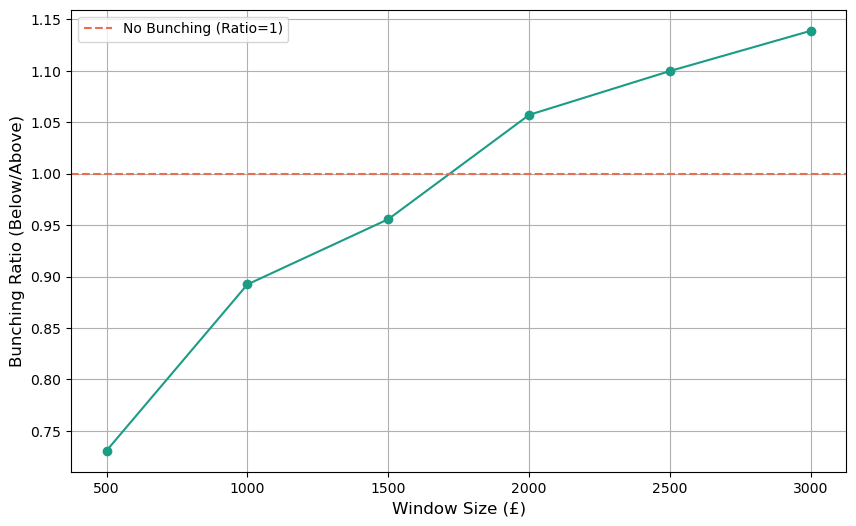

In [65]:
optimal_window = plot_threshold_sensitivity(sensitivity_results)
#print(f"Suggested optimal window: £{optimal_window}")

We determined that the optimal bandwidth is **window = £500**.  
All subsequent analyses are based on this specification, and the treatment group is defined accordingly.  
For robustness checks, alternative bandwidths of **±£1,000** and **±£1,500** are examined (see [Robustness Checks](#Robustness-Checks))


# Descriptive Analysis

## Regional Differential Analysis

In [66]:
def calculate_rv_changes(df, baseline_timepoint='-12', comparison_timepoint='0'):
    """
    Calculate RV changes between baseline and comparison timepoints
    """
    # Extract baseline data (12 months before revaluation)
    baseline = df[df['timepoint'] == baseline_timepoint].copy()
    baseline = baseline[['uarn', 'rateable_value', 'borough', 'category_group']].rename(
        columns={'rateable_value': 'rv_baseline'})
    
    # Extract comparison data (revaluation point)
    comparison = df[df['timepoint'] == comparison_timepoint].copy()
    comparison = comparison[['uarn', 'rateable_value']].rename(
        columns={'rateable_value': 'rv_revaluation'})
    
    # Merge and calculate changes
    rv_changes = baseline.merge(comparison, on='uarn', how='inner')
    rv_changes['rv_change_absolute'] = rv_changes['rv_revaluation'] - rv_changes['rv_baseline']
    rv_changes['rv_change_pct'] = (rv_changes['rv_change_absolute'] / rv_changes['rv_baseline']) * 100
    
    return rv_changes

In [67]:
def analyze_borough_rv_differences(df, baseline_timepoint='-12', comparison_timepoint='0'):
    """
    Analyze RV change patterns across different boroughs
    """
    
    # Calculate RV changes by borough
    rv_changes = calculate_rv_changes(df, baseline_timepoint, comparison_timepoint)
    
    # Borough-level statistics
    borough_stats = rv_changes.groupby('borough').agg({
        'rv_change_pct': ['count', 'mean', 'median', 'std'],
        'rv_change_absolute': ['mean', 'median'],
        'rv_baseline': ['mean', 'median']
    }).round(2)
    
    # Flatten column names
    borough_stats.columns = ['_'.join(col).strip() for col in borough_stats.columns]
    
    # Plot borough differences
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # RV change percentage by borough
    sns.boxplot(data=rv_changes, x='borough', y='rv_change_pct', ax=axes[0,0])
    axes[0,0].set_title('RV Change Distribution by Borough')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].set_ylabel('RV Change (%)')
    
    # Mean RV change by borough
    mean_changes = rv_changes.groupby('borough')['rv_change_pct'].mean()
    bars = axes[0,1].bar(mean_changes.index, mean_changes.values)
    axes[0,1].set_title('Average RV Change by Borough')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].set_ylabel('Average RV Change (%)')
    
    # Add value labels on bars
    for bar, value in zip(bars, mean_changes.values):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                       f'{value:.1f}%', ha='center', va='bottom')
    
    # Business count by borough
    business_counts = rv_changes.groupby('borough').size()
    axes[1,0].pie(business_counts.values, labels=business_counts.index, autopct='%1.1f%%')
    axes[1,0].set_title('Business Distribution by Borough')
    
    # RV baseline distribution by borough
    sns.boxplot(data=rv_changes, x='borough', y='rv_baseline', ax=axes[1,1])
    axes[1,1].set_title('Baseline RV Distribution by Borough')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].set_ylabel('Baseline RV (£)')
    
    plt.tight_layout()
    plt.show()
    
    return borough_stats, rv_changes

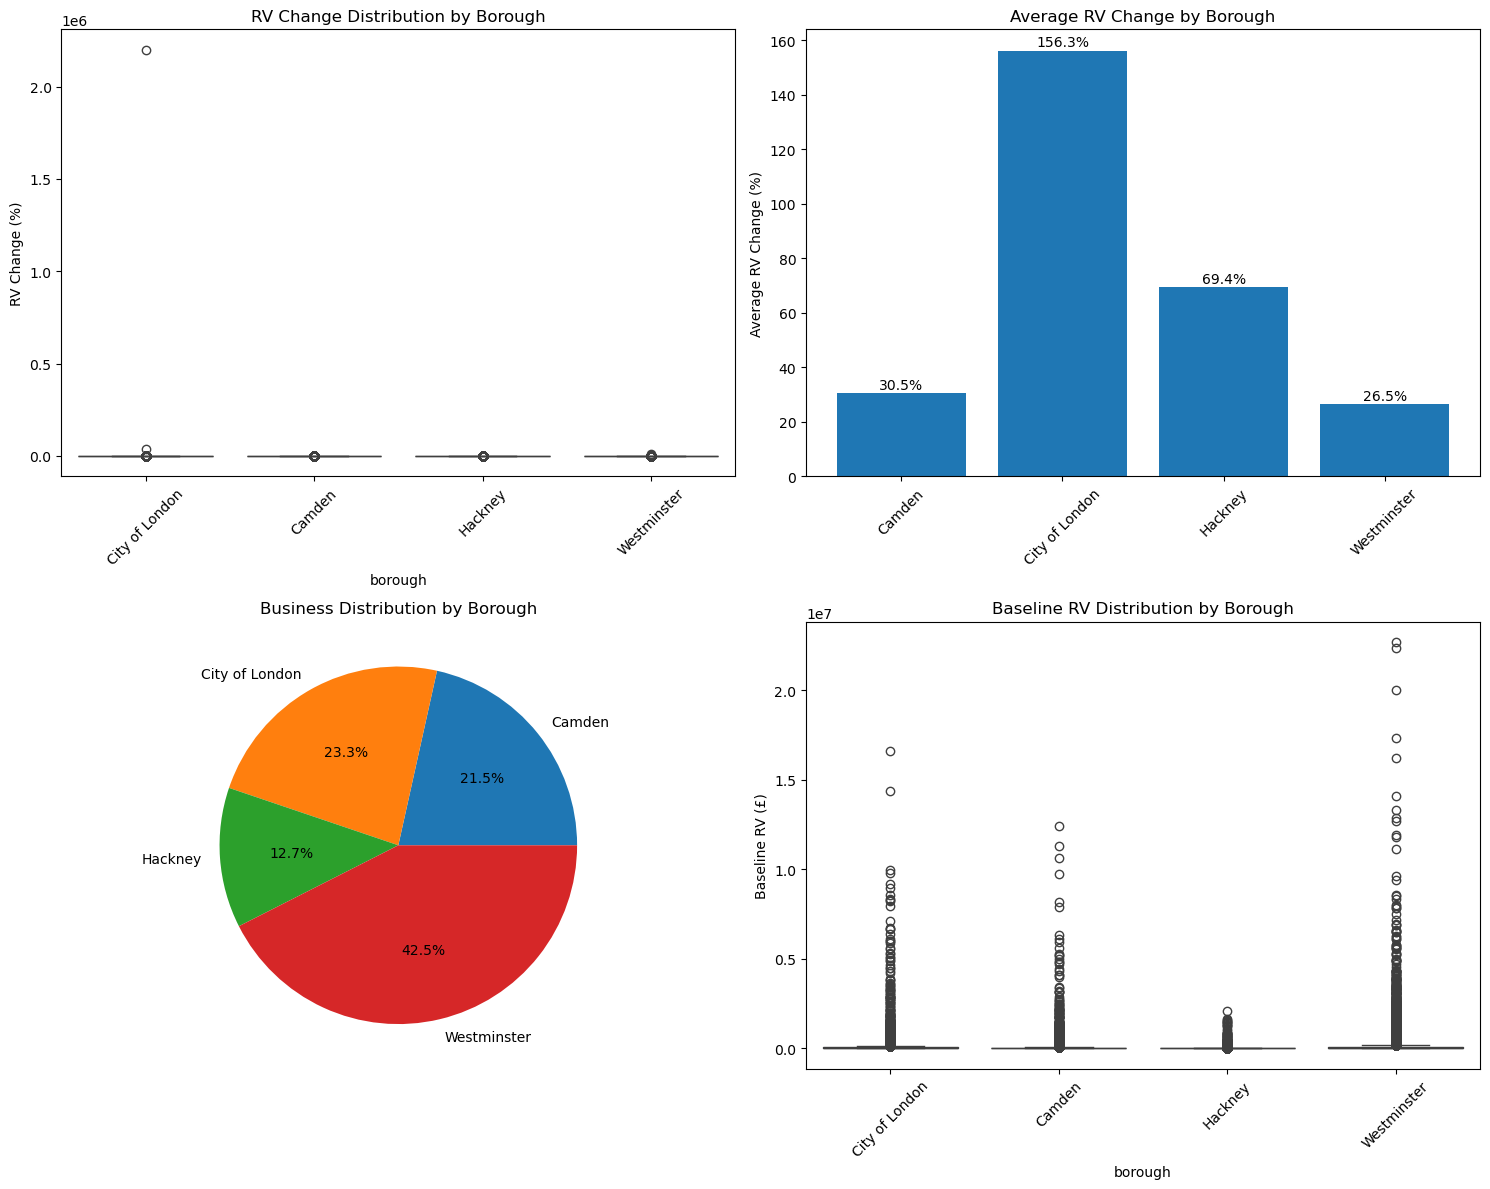

(                rv_change_pct_count  rv_change_pct_mean  rv_change_pct_median  \
 borough                                                                         
 Camden                        16803               30.54                 23.81   
 City of London                18165              156.27                 30.95   
 Hackney                        9895               69.42                 49.65   
 Westminster                   33191               26.53                 16.67   
 
                 rv_change_pct_std  rv_change_absolute_mean  \
 borough                                                      
 Camden                      42.36                 19922.80   
 City of London           16324.64                 27224.81   
 Hackney                     81.04                 10374.41   
 Westminster                 69.18                 31900.10   
 
                 rv_change_absolute_median  rv_baseline_mean  \
 borough                                                      

In [68]:
analyze_borough_rv_differences(data_2017)

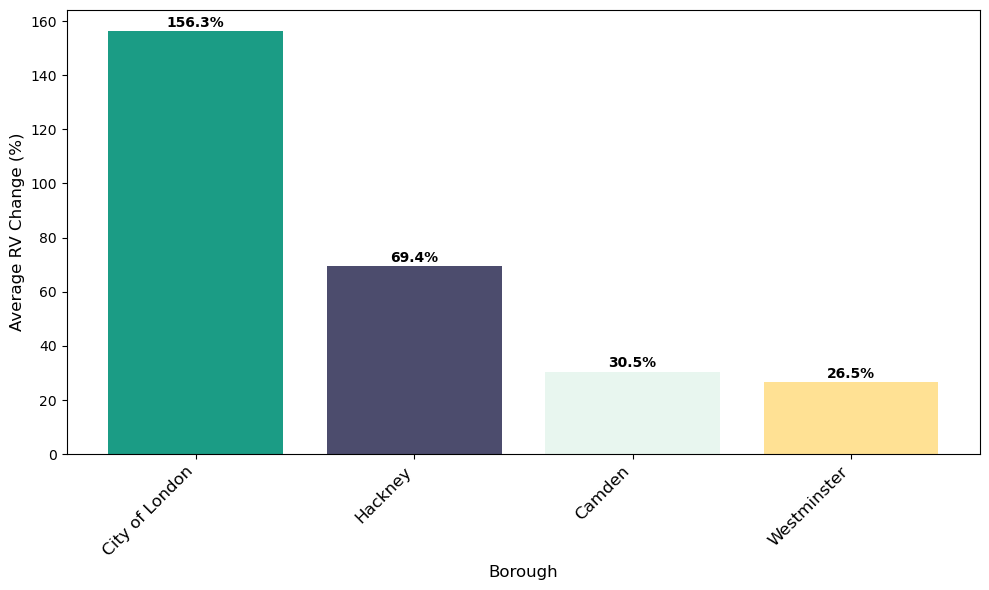

In [69]:
rv_changes = calculate_rv_changes(data_2017)

# Calculate the average RV change for each borough
mean_changes = rv_changes.groupby('borough')['rv_change_pct'].mean().sort_values(ascending=False)

# Create a standalone bar chart
fig, ax = plt.subplots(figsize=(10, 6))

borough_color_map = {
    'Westminster': '#ffe194',
    'Camden': '#e8f6ef', 
    'City of London': '#1b9c85',
    'Hackney': '#4c4c6d'
}

bar_colors = [borough_color_map.get(borough, '#cccccc') for borough in mean_changes.index]
bars = ax.bar(range(len(mean_changes)), mean_changes.values, color=bar_colors)

#ax.set_title('Average RV Change by Borough', fontsize=14, fontweight='bold')
ax.set_ylabel('Average RV Change (%)',fontsize=12)
ax.set_xlabel('Borough',fontsize=12)

ax.set_xticks(range(len(mean_changes)))
ax.set_xticklabels(mean_changes.index, rotation=45, ha='right',fontsize=12)

for i, (bar, value) in enumerate(zip(bars, mean_changes.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')


# Adjust layout
plt.tight_layout()
#plt.savefig('borough_rv_changes.png', dpi=300, bbox_inches='tight')
plt.show()

In [70]:
# Summarize the data
print("Borough RV Change Summary:")
for borough, change in mean_changes.items():
    print(f"{borough}: {change:.2f}%")

Borough RV Change Summary:
City of London: 156.27%
Hackney: 69.42%
Camden: 30.54%
Westminster: 26.53%


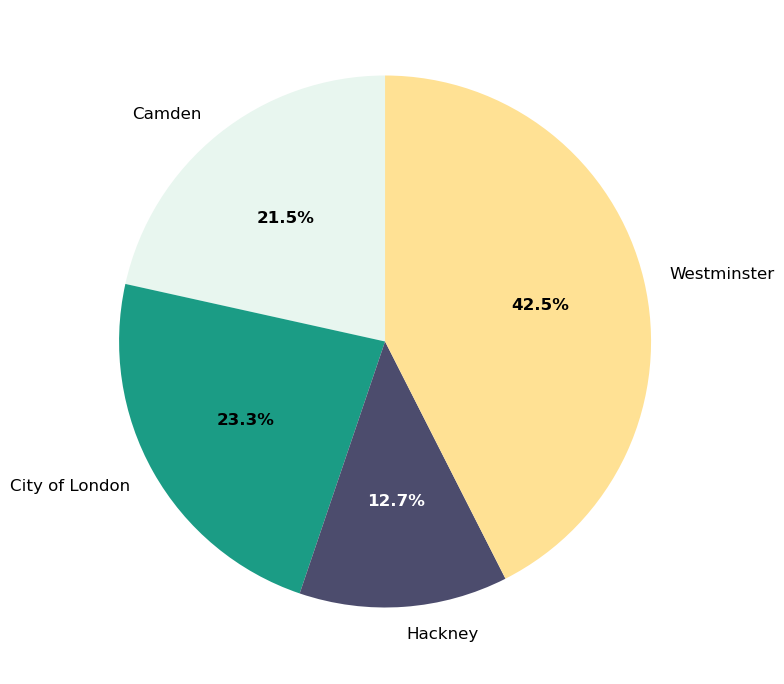

In [71]:
# Calculate the number of businesses in each borough
business_counts = rv_changes.groupby('borough').size()

# Create a pie chart
fig, ax = plt.subplots(figsize=(8, 8))

borough_color_map = {
    'Westminster': '#ffe194',
    'Camden': '#e8f6ef', 
    'City of London': '#1b9c85',
    'Hackney': '#4c4c6d'
}

pie_colors = [borough_color_map.get(borough, '#cccccc') for borough in business_counts.index]

wedges, texts, autotexts = ax.pie(business_counts.values, 
                                  labels=business_counts.index, 
                                  autopct='%1.1f%%',
                                  colors=pie_colors,
                                  startangle=90)


#ax.set_title('Business Distribution by Borough', fontsize=14, fontweight='bold')
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

for borough, autotext in zip(business_counts.index, autotexts):
    if borough == 'Hackney':
        autotext.set_color('white')

plt.tight_layout()
#plt.savefig('business_distribution_by_borough.png', dpi=300, bbox_inches='tight')
plt.show()
  

In [72]:
# 显示数据摘要
print("Business Count by Borough:")
for borough, count in business_counts.items():
    percentage = (count / business_counts.sum()) * 100
    print(f"{borough}: {count} businesses ({percentage:.1f}%)")
 

Business Count by Borough:
Camden: 16803 businesses (21.5%)
City of London: 18165 businesses (23.3%)
Hackney: 9895 businesses (12.7%)
Westminster: 33191 businesses (42.5%)


## Size-Based Stratification

In [73]:
def analyze_size_heterogeneity(df, baseline_timepoint='-12', comparison_timepoint='0', n_quantiles=4):
    """
    Analyze heterogeneous responses across different business sizes (RV baseline quantiles)
    """
    
    # Get RV changes data
    rv_changes = calculate_rv_changes(df, baseline_timepoint, comparison_timepoint)
    
    # Create size quantiles based on baseline RV
    rv_changes['size_quantile'] = pd.qcut(rv_changes['rv_baseline'], 
                                         q=n_quantiles, 
                                         labels=[f'Q{i+1}' for i in range(n_quantiles)])
    
    # Calculate quantile boundaries for interpretation
    quantile_bounds = rv_changes.groupby('size_quantile')['rv_baseline'].agg(['min', 'max', 'median'])
    
    # Size-specific response analysis
    size_responses = rv_changes.groupby('size_quantile').agg({
        'rv_change_pct': ['count', 'mean', 'median', 'std'],
        'rv_change_absolute': ['mean', 'median'],
        'rv_baseline': ['mean', 'median']
    }).round(2)
    
    # Flatten column names
    size_responses.columns = ['_'.join(col).strip() for col in size_responses.columns]
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. RV change percentage by size quantile
    sns.boxplot(data=rv_changes, x='size_quantile', y='rv_change_pct', ax=axes[0,0])
    axes[0,0].set_title('RV Change Distribution by Business Size Quantile')
    axes[0,0].set_xlabel('Size Quantile (Based on Baseline RV)')
    axes[0,0].set_ylabel('RV Change (%)')
    
    # 2. Mean RV change by quantile
    mean_changes = rv_changes.groupby('size_quantile')['rv_change_pct'].mean()
    bars = axes[0,1].bar(mean_changes.index, mean_changes.values)
    axes[0,1].set_title('Average RV Change by Size Quantile')
    axes[0,1].set_xlabel('Size Quantile')
    axes[0,1].set_ylabel('Average RV Change (%)')
    
    # Add value labels
    for bar, value in zip(bars, mean_changes.values):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       f'{value:.1f}%', ha='center', va='bottom')
    
    # 3. Size quantile composition by borough
    size_borough = pd.crosstab(rv_changes['size_quantile'], rv_changes['borough'], normalize='index') * 100
    size_borough.plot(kind='bar', stacked=True, ax=axes[1,0])
    axes[1,0].set_title('Size Quantile Composition by Borough (%)')
    axes[1,0].set_xlabel('Size Quantile')
    axes[1,0].set_ylabel('Percentage')
    axes[1,0].legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 4. Size quantile composition by industry
    size_industry = pd.crosstab(rv_changes['size_quantile'], rv_changes['category_group'], normalize='index') * 100
    size_industry.plot(kind='bar', stacked=True, ax=axes[1,1])
    axes[1,1].set_title('Size Quantile Composition by Industry (%)')
    axes[1,1].set_xlabel('Size Quantile')
    axes[1,1].set_ylabel('Percentage')
    axes[1,1].legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    return size_responses, quantile_bounds, rv_changes

def analyze_threshold_by_size(df, threshold=15000, window=500, timepoint='0'):
    """
    Analyze threshold effects across different size quantiles
    """
    # Get data for specific timepoint
    timepoint_data = df[df['timepoint'] == timepoint].copy()
    
    # Create size quantiles
    timepoint_data['size_quantile'] = pd.qcut(timepoint_data['rateable_value'], 
                                             q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    # Threshold analysis by size
    threshold_effects = {}
    
    for quantile in ['Q1', 'Q2', 'Q3', 'Q4']:
        quantile_data = timepoint_data[timepoint_data['size_quantile'] == quantile]
        
        # Count businesses near threshold
        near_threshold = quantile_data[
            (quantile_data['rateable_value'] >= threshold - window) & 
            (quantile_data['rateable_value'] <= threshold + window)
        ].shape[0]
        
        below_threshold = quantile_data[
            (quantile_data['rateable_value'] >= threshold - window) & 
            (quantile_data['rateable_value'] < threshold)
        ].shape[0]
        
        above_threshold = quantile_data[
            (quantile_data['rateable_value'] >= threshold) & 
            (quantile_data['rateable_value'] <= threshold + window)
        ].shape[0]
        
        bunching_ratio = below_threshold / above_threshold if above_threshold > 0 else 0
        
        threshold_effects[quantile] = {
            'total_businesses': quantile_data.shape[0],
            'near_threshold': near_threshold,
            'below_threshold': below_threshold,
            'above_threshold': above_threshold,
            'bunching_ratio': bunching_ratio,
            'threshold_exposure': near_threshold / quantile_data.shape[0] if quantile_data.shape[0] > 0 else 0
        }
    
    return threshold_effects

# Usage example combining both analyses
def comprehensive_size_analysis(df):
    """
    Comprehensive analysis combining size heterogeneity and threshold effects
    """
    print("=== SIZE HETEROGENEITY ANALYSIS ===")
    size_responses, quantile_bounds, rv_changes_with_size = analyze_size_heterogeneity(df)
    
    print("\nQuantile Boundaries (£):")
    print(quantile_bounds)
    
    print("\nSize-specific Responses:")
    print(size_responses)
    
    print("\n=== THRESHOLD EFFECTS BY SIZE ===")
    threshold_by_size = analyze_threshold_by_size(df, threshold=15000, window=500)
    
    for quantile, effects in threshold_by_size.items():
        print(f"\n{quantile}:")
        print(f"  Total businesses: {effects['total_businesses']:,}")
        print(f"  Near threshold (±£500): {effects['near_threshold']:,}")
        print(f"  Threshold exposure: {effects['threshold_exposure']:.1%}")
        print(f"  Bunching ratio: {effects['bunching_ratio']:.3f}")
    
    return size_responses, threshold_by_size, rv_changes_with_size

=== SIZE HETEROGENEITY ANALYSIS ===


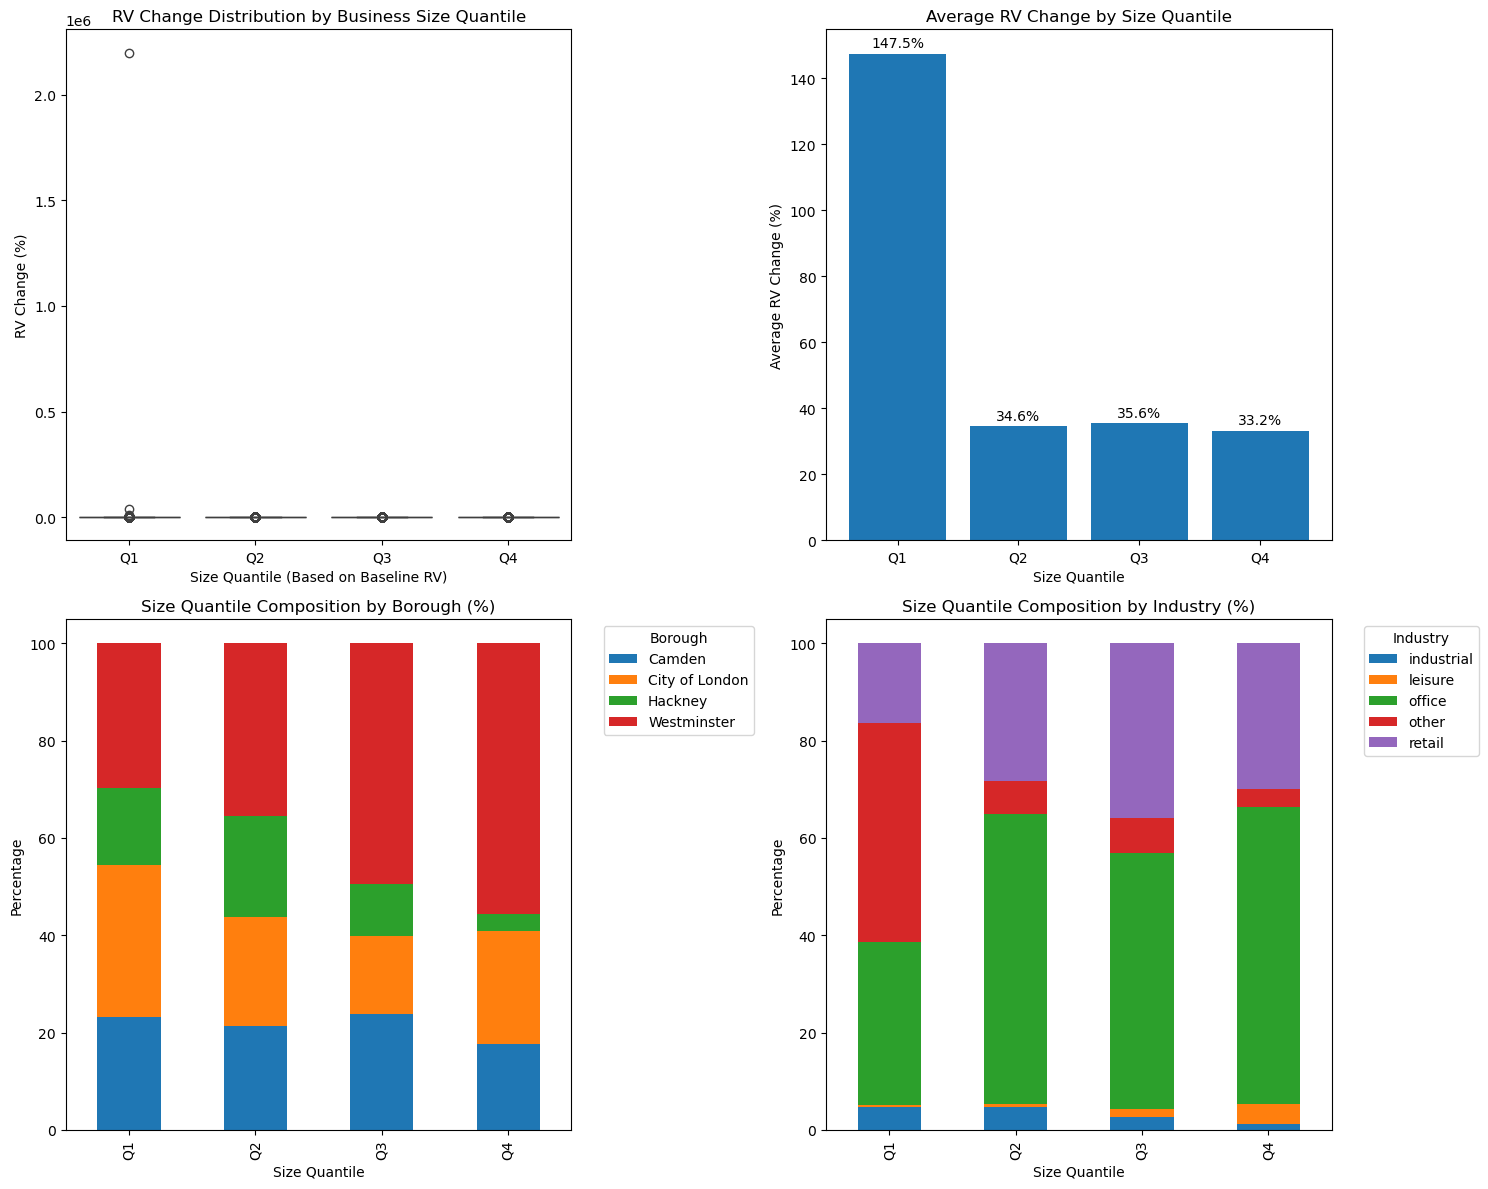


Quantile Boundaries (£):
                   min         max    median
size_quantile                               
Q1                 1.0      5400.0    3000.0
Q2              5500.0     16500.0   10000.0
Q3             16750.0     53500.0   27750.0
Q4             53750.0  22700000.0  127000.0

Size-specific Responses:
               rv_change_pct_count  rv_change_pct_mean  rv_change_pct_median  \
size_quantile                                                                  
Q1                           19709              147.50                 11.43   
Q2                           19439               34.62                 26.83   
Q3                           19412               35.60                 27.87   
Q4                           19494               33.24                 25.89   

               rv_change_pct_std  rv_change_absolute_mean  \
size_quantile                                               
Q1                      15672.44                   937.71   
Q2            

(               rv_change_pct_count  rv_change_pct_mean  rv_change_pct_median  \
 size_quantile                                                                  
 Q1                           19709              147.50                 11.43   
 Q2                           19439               34.62                 26.83   
 Q3                           19412               35.60                 27.87   
 Q4                           19494               33.24                 25.89   
 
                rv_change_pct_std  rv_change_absolute_mean  \
 size_quantile                                               
 Q1                      15672.44                   937.71   
 Q2                         43.42                  3548.80   
 Q3                         43.59                 10905.97   
 Q4                         37.08                 86774.36   
 
                rv_change_absolute_median  rv_baseline_mean  rv_baseline_median  
 size_quantile                                          

In [74]:
comprehensive_size_analysis(data_2017)

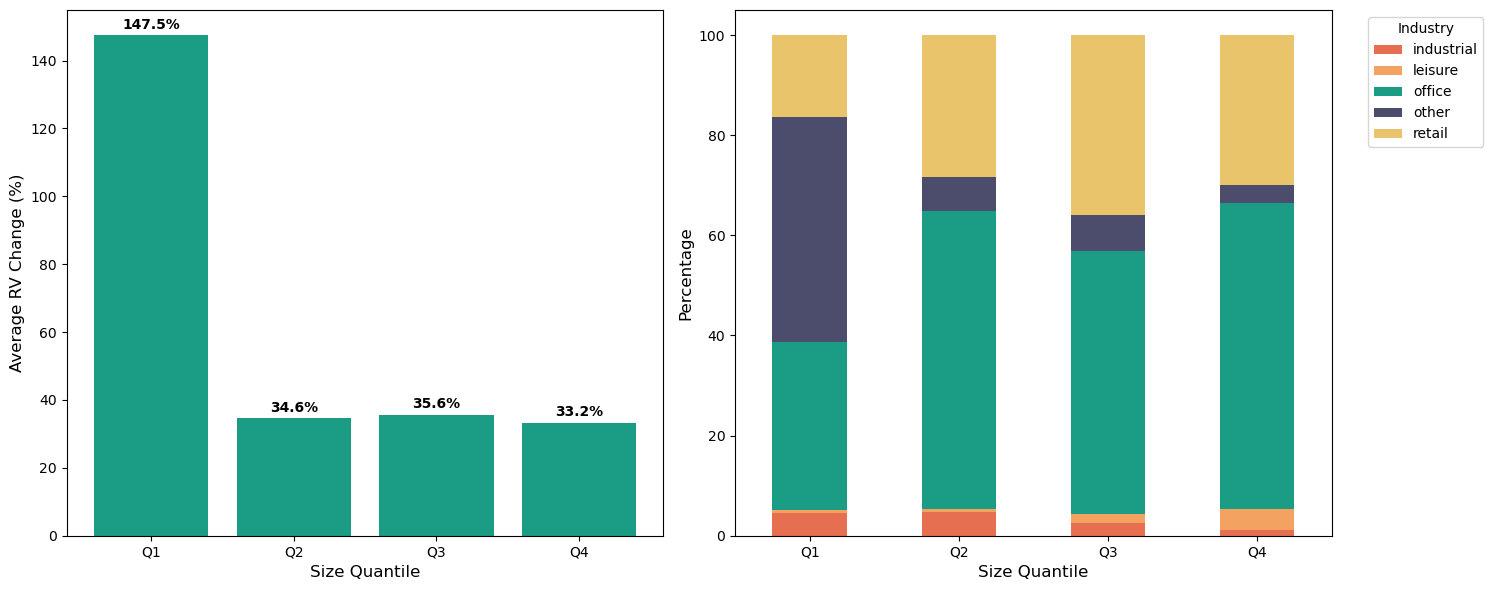

In [75]:
def analyze_size_heterogeneity_selected(df, baseline_timepoint='-12', comparison_timepoint='0', n_quantiles=4):
    """
    Create selected visualizations: Mean RV change by quantile and Size composition by industry
    """
    
    # Get RV changes data
    rv_changes = calculate_rv_changes(df, baseline_timepoint, comparison_timepoint)
    
    # Create size quantiles based on baseline RV
    rv_changes['size_quantile'] = pd.qcut(rv_changes['rv_baseline'], 
                                         q=n_quantiles, 
                                         labels=[f'Q{i+1}' for i in range(n_quantiles)])
    
    # Create visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # P1: Mean RV change by quantile
    mean_changes = rv_changes.groupby('size_quantile')['rv_change_pct'].mean()
    bars = ax1.bar(mean_changes.index, mean_changes.values, color='#1b9c85')
    #ax1.set_title('Average RV Change by Size Quantile', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Size Quantile', fontsize=12)
    ax1.set_ylabel('Average RV Change (%)', fontsize=12)
    
    # Add value labels
    for bar, value in zip(bars, mean_changes.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # P2: Size quantile composition by industry
    size_industry = pd.crosstab(rv_changes['size_quantile'], rv_changes['category_group'], normalize='index') * 100
    size_industry.plot(kind='bar', stacked=True, ax=ax2, 
                       color=['#e76f51', '#f4a261', '#1b9c85', '#4c4c6d','#e9c46a'])
    #ax2.set_title('Size Quantile Composition by Industry (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Size Quantile', fontsize=12)
    ax2.set_ylabel('Percentage', fontsize=12)
    ax2.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    #plt.savefig('size_analysis_selected.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return rv_changes

rv_changes_with_size = analyze_size_heterogeneity_selected(data_2017)

## Sectoral Impact Assessment

In [76]:
def analyze_category_changes(df, timepoints=['0', '+6', '+12', '+24']):
    """
    Analyze industry composition and stability over time
    """
    
    # Business count by category and timepoint
    category_evolution = df.groupby(['timepoint', 'category_group']).size().unstack(fill_value=0)
    
    # Calculate change rates
    if '0' in category_evolution.index:
        baseline = category_evolution.loc['0']
        change_rates = {}
        
        for tp in timepoints[1:]:  # Skip baseline timepoint '0'
            if tp in category_evolution.index:
                change_rates[tp] = ((category_evolution.loc[tp] - baseline) / baseline * 100).round(2)
    
    # Industry stability metrics
    stability_metrics = {}
    for category in df['category_group'].unique():
        if pd.notna(category):
            cat_data = category_evolution[category]
            stability_metrics[category] = {
                'volatility': cat_data.std(),
                'cv': cat_data.std() / cat_data.mean() if cat_data.mean() > 0 else 0,
                'total_change': cat_data.iloc[-1] - cat_data.iloc[0] if len(cat_data) > 1 else 0
            }
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Industry composition over time
    category_evolution.T.plot(kind='bar', stacked=True, ax=axes[0,0])
    axes[0,0].set_title('Industry Composition Over Time')
    axes[0,0].set_xlabel('Industry')
    axes[0,0].set_ylabel('Number of Businesses')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].legend(title='Timepoint', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Industry change rates (if available)
    if change_rates:
        change_df = pd.DataFrame(change_rates).T
        sns.heatmap(change_df, annot=True, cmap='RdBu_r', center=0, ax=axes[0,1])
        axes[0,1].set_title('Industry Change Rates (%)')
        axes[0,1].set_xlabel('Industry')
        axes[0,1].set_ylabel('Timepoint')
    
    # Industry volatility
    volatility = [stability_metrics[cat]['volatility'] for cat in stability_metrics.keys()]
    industries = list(stability_metrics.keys())
    bars = axes[1,0].bar(industries, volatility)
    axes[1,0].set_title('Industry Volatility (Standard Deviation)')
    axes[1,0].set_xlabel('Industry')
    axes[1,0].set_ylabel('Volatility')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # RV sensitivity by industry
    if 'rv_change_pct' in df.columns:
        sns.boxplot(data=df[df['timepoint']=='0'], x='category_group', y='rv_change_pct', ax=axes[1,1])
        axes[1,1].set_title('RV Change Sensitivity by Industry')
        axes[1,1].set_xlabel('Industry')
        axes[1,1].set_ylabel('RV Change (%)')
        axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return category_evolution, stability_metrics, change_rates if 'change_rates' in locals() else None

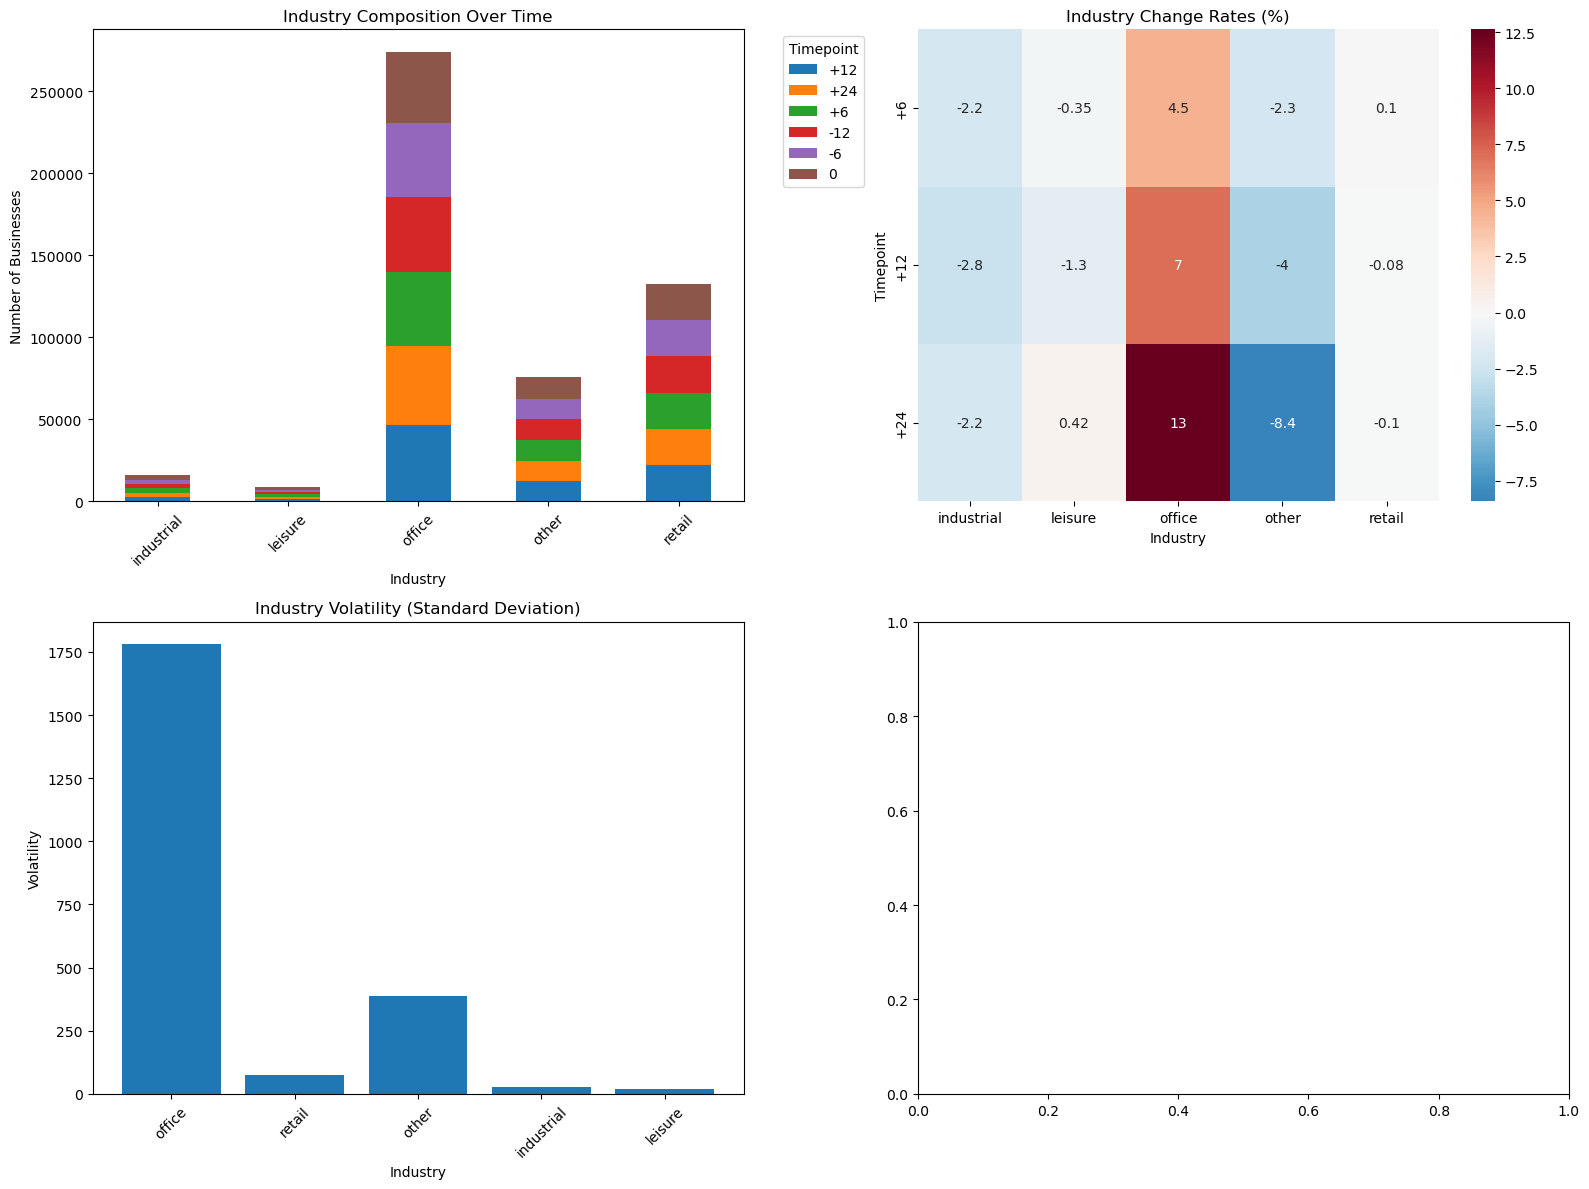

(category_group  industrial  leisure  office  other  retail
 timepoint                                                 
 +12                   2634     1416   46280  12665   22120
 +24                   2650     1441   48695  12089   22116
 +6                    2648     1430   45169  12892   22161
 -12                   2663     1396   45415  12526   22002
 -6                    2663     1396   45403  12395   21987
 0                     2709     1435   43233  13200   22138,
 {'office': {'volatility': 1780.1070098920081,
   'cv': 0.0389527236432176,
   'total_change': -3047},
  'retail': {'volatility': 73.79882564557967,
   'cv': 0.0033412284105028374,
   'total_change': 18},
  'other': {'volatility': 388.19140467901485,
   'cv': 0.03074093507825424,
   'total_change': 535},
  'industrial': {'volatility': 25.810204700208534,
   'cv': 0.009698830600692128,
   'total_change': 75},
  'leisure': {'volatility': 19.636700333813724,
   'cv': 0.013838407564350758,
   'total_change': 19}},
 {'

In [77]:
analyze_category_changes(data_2017)

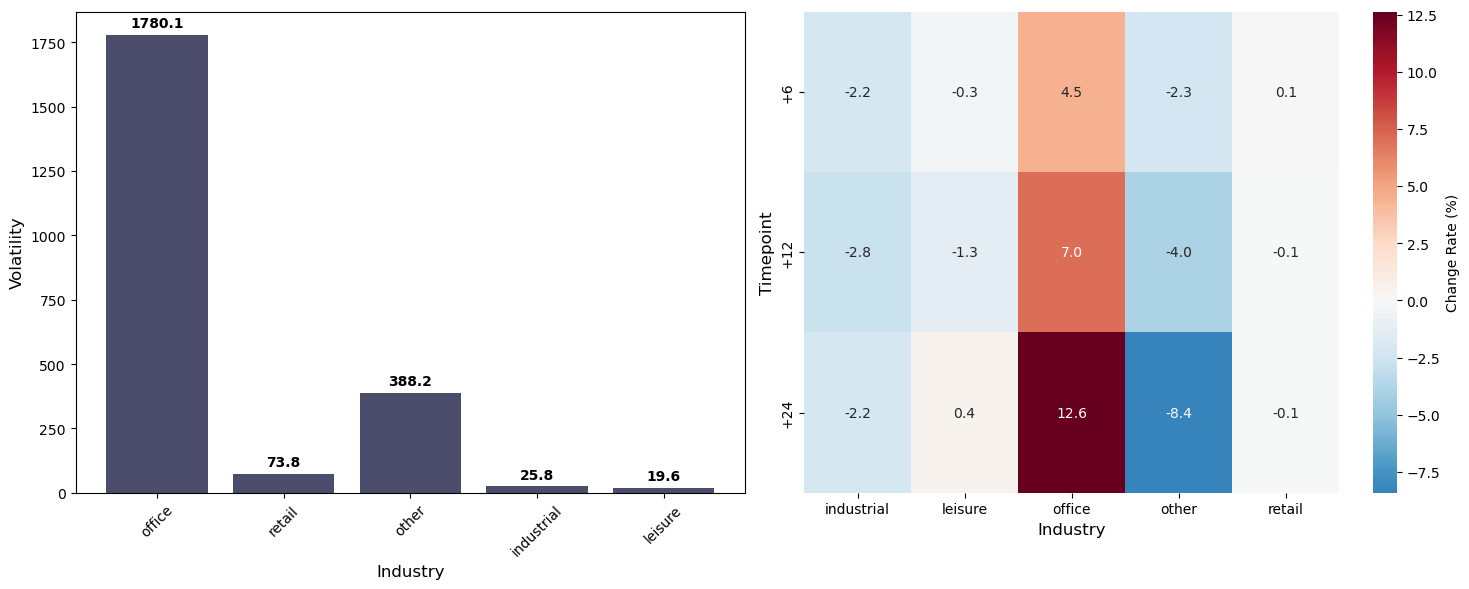

In [78]:
def analyze_category_changes_selected(df, timepoints=['0', '+6', '+12', '+24']):
    """
    Create selected visualizations: Industry change rates heatmap and Industry volatility
    """
    
    # Business count by category and timepoint
    category_evolution = df.groupby(['timepoint', 'category_group']).size().unstack(fill_value=0)
    
    # Calculate change rates
    change_rates = None
    if '0' in category_evolution.index:
        baseline = category_evolution.loc['0']
        change_rates = {}
        
        for tp in timepoints[1:]:  # Skip baseline timepoint '0'
            if tp in category_evolution.index:
                change_rates[tp] = ((category_evolution.loc[tp] - baseline) / baseline * 100).round(2)
    
    # Industry stability metrics
    stability_metrics = {}
    for category in df['category_group'].unique():
        if pd.notna(category):
            cat_data = category_evolution[category]
            stability_metrics[category] = {
                'volatility': cat_data.std(),
                'cv': cat_data.std() / cat_data.mean() if cat_data.mean() > 0 else 0,
                'total_change': cat_data.iloc[-1] - cat_data.iloc[0] if len(cat_data) > 1 else 0
            }
    
    # Create visualizations
    fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Industry change rates heatmap
    if change_rates:
        change_df = pd.DataFrame(change_rates).T
        sns.heatmap(change_df, annot=True, cmap='RdBu_r', center=0, ax=ax1, 
                   fmt='.1f', cbar_kws={'label': 'Change Rate (%)'})
        #ax1.set_title('Industry Change Rates (%)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Industry', fontsize=12)
        ax1.set_ylabel('Timepoint', fontsize=12)
    
    # Industry volatility
    volatility = [stability_metrics[cat]['volatility'] for cat in stability_metrics.keys()]
    industries = list(stability_metrics.keys())
    bars = ax2.bar(industries, volatility, color='#4c4c6d')
    #ax2.set_title('Industry Volatility (Standard Deviation)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Industry', fontsize=12)
    ax2.set_ylabel('Volatility', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, volatility):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(volatility)*0.01,
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    #plt.savefig('industry_analysis_selected.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return category_evolution, stability_metrics, change_rates

category_evolution, stability_metrics, change_rates = analyze_category_changes_selected(data_2017)

## Business Survival Patterns

In [79]:
def analyze_exit_patterns(df, survival_timepoints=['+6', '+12', '+24']):
    """
    Analyze business exit patterns by industry and characteristics
    """
    
    # Create survival indicators
    baseline_businesses = set(df[df['timepoint'] == '0']['uarn'].unique())
    
    exit_analysis = {}
    survival_rates = {}
    
    for tp in survival_timepoints:
        surviving_businesses = set(df[df['timepoint'] == tp]['uarn'].unique())
        exited_businesses = baseline_businesses - surviving_businesses
        
        survival_rate = len(surviving_businesses) / len(baseline_businesses)
        exit_rate = len(exited_businesses) / len(baseline_businesses)
        
        exit_analysis[tp] = {
            'survival_count': len(surviving_businesses),
            'exit_count': len(exited_businesses),
            'survival_rate': survival_rate,
            'exit_rate': exit_rate
        }
    
    # Industry-specific exit patterns
    baseline_df = df[df['timepoint'] == '0'].copy()
    industry_exit = {}
    
    for industry in baseline_df['category_group'].dropna().unique():
        industry_businesses = set(baseline_df[baseline_df['category_group'] == industry]['uarn'].unique())
        
        industry_exit[industry] = {}
        for tp in survival_timepoints:
            surviving = set(df[df['timepoint'] == tp]['uarn'].unique())
            industry_surviving = industry_businesses & surviving
            
            if len(industry_businesses) > 0:
                industry_exit[industry][tp] = {
                    'survival_rate': len(industry_surviving) / len(industry_businesses),
                    'exit_rate': 1 - (len(industry_surviving) / len(industry_businesses))
                }
    
    # Create exit pattern visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Overall survival rates over time
    timepoints = list(exit_analysis.keys())
    survival_rates = [exit_analysis[tp]['survival_rate'] for tp in timepoints]
    exit_rates = [exit_analysis[tp]['exit_rate'] for tp in timepoints]
    
    axes[0,0].plot(timepoints, survival_rates, 'o-', label='Survival Rate', linewidth=2)
    axes[0,0].plot(timepoints, exit_rates, 's-', label='Exit Rate', linewidth=2)
    axes[0,0].set_title('Overall Business Survival/Exit Rates')
    axes[0,0].set_xlabel('Timepoint')
    axes[0,0].set_ylabel('Rate')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Industry-specific survival rates
    industry_survival_df = pd.DataFrame({
        industry: {tp: industry_exit[industry][tp]['survival_rate'] 
                  for tp in survival_timepoints if tp in industry_exit[industry]}
        for industry in industry_exit.keys()
    })
    
    for industry in industry_survival_df.columns:
        if not industry_survival_df[industry].isna().all():
            axes[0,1].plot(industry_survival_df.index, industry_survival_df[industry], 
                          'o-', label=industry, linewidth=2)
    
    axes[0,1].set_title('Survival Rates by Industry')
    axes[0,1].set_xlabel('Timepoint')
    axes[0,1].set_ylabel('Survival Rate')
    axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0,1].grid(True)
    
    # Exit counts by timepoint
    exit_counts = [exit_analysis[tp]['exit_count'] for tp in timepoints]
    bars = axes[1,0].bar(timepoints, exit_counts)
    axes[1,0].set_title('Business Exit Counts by Timepoint')
    axes[1,0].set_xlabel('Timepoint')
    axes[1,0].set_ylabel('Number of Exits')
    
    # Add value labels
    for bar, count in zip(bars, exit_counts):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(exit_counts)*0.01,
                       f'{count:,}', ha='center', va='bottom')
    
    # Industry exit vulnerability (final timepoint)
    final_tp = survival_timepoints[-1]
    industry_final_exit = {industry: industry_exit[industry][final_tp]['exit_rate'] 
                          for industry in industry_exit.keys() 
                          if final_tp in industry_exit[industry]}
    
    industries = list(industry_final_exit.keys())
    exit_rates_final = list(industry_final_exit.values())
    
    bars = axes[1,1].bar(industries, exit_rates_final)
    axes[1,1].set_title(f'Industry Exit Rates at {final_tp} Months')
    axes[1,1].set_xlabel('Industry')
    axes[1,1].set_ylabel('Exit Rate')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, rate in zip(bars, exit_rates_final):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(exit_rates_final)*0.01,
                       f'{rate:.1%}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return exit_analysis, industry_exit, industry_survival_df

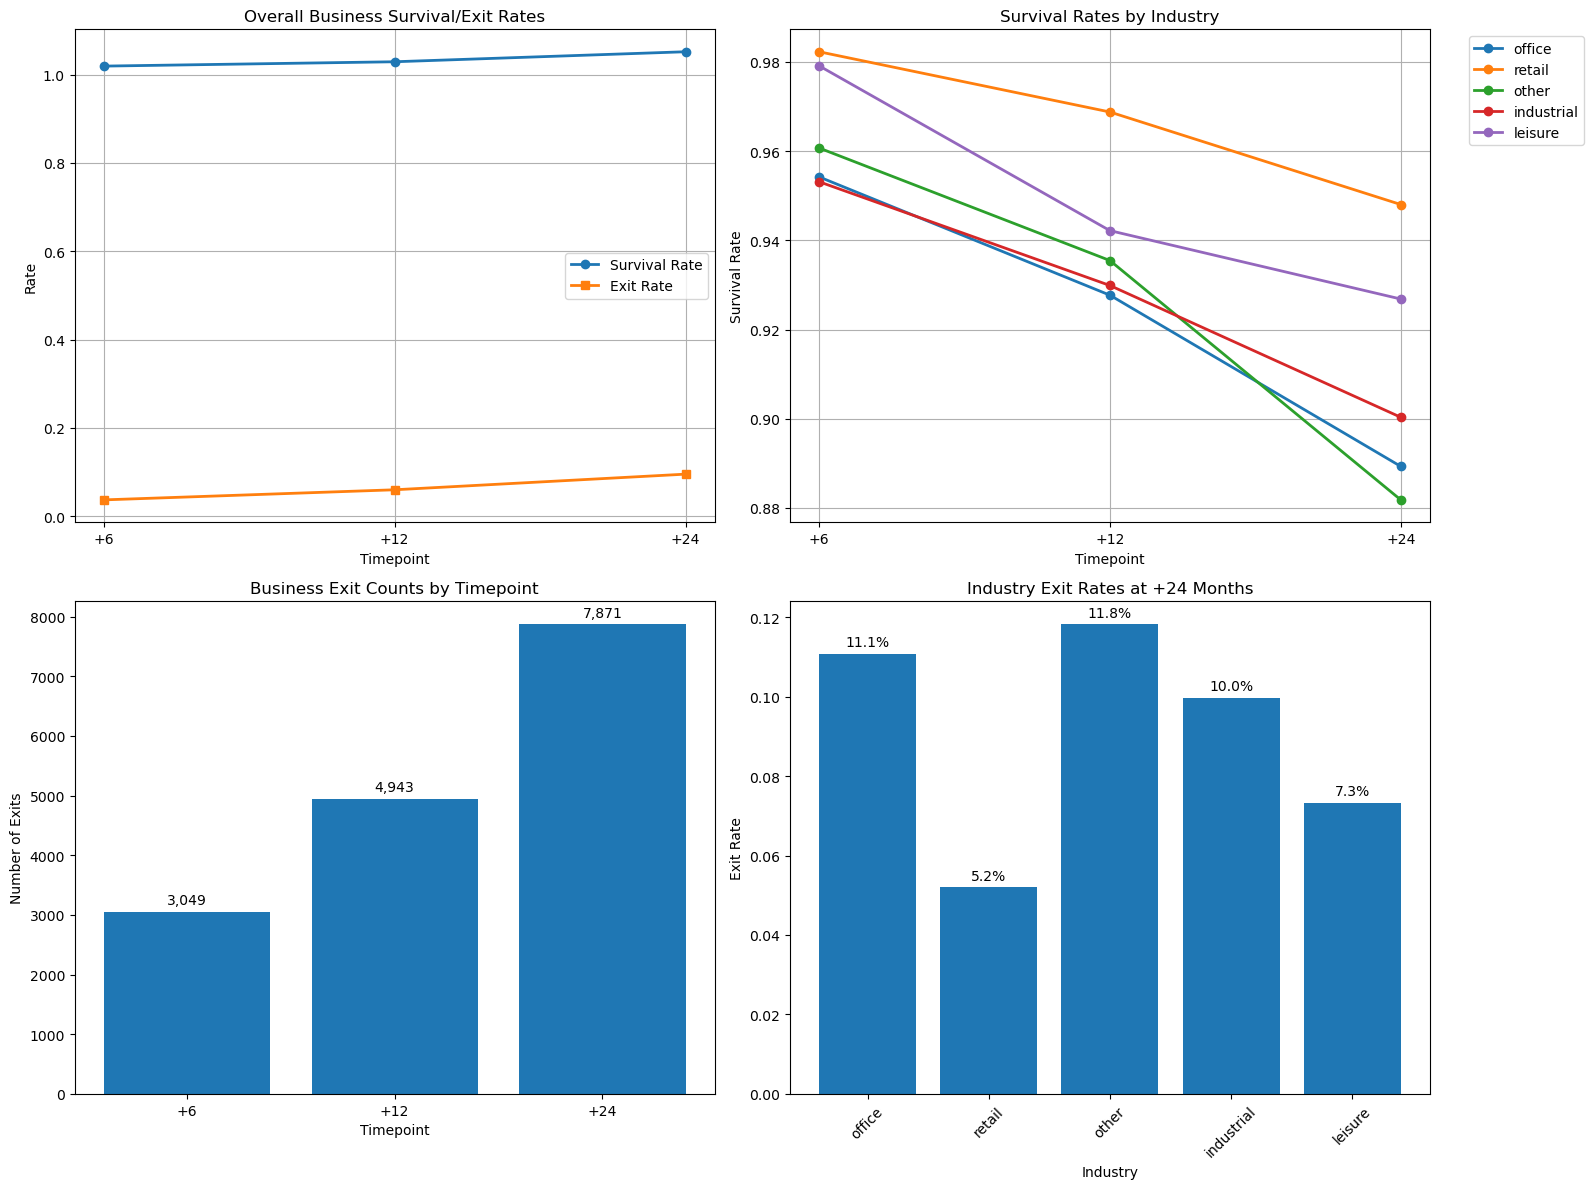

({'+6': {'survival_count': 84300,
   'exit_count': 3049,
   'survival_rate': 1.0191621834008342,
   'exit_rate': 0.03686151242217252},
  '+12': {'survival_count': 85115,
   'exit_count': 4943,
   'survival_rate': 1.0290152934776038,
   'exit_rate': 0.0597594148582482},
  '+24': {'survival_count': 86991,
   'exit_count': 7871,
   'survival_rate': 1.0516955812125974,
   'exit_rate': 0.09515807290092486}},
 {'office': {'+6': {'survival_rate': 0.954201651516203,
    'exit_rate': 0.04579834848379705},
   '+12': {'survival_rate': 0.9276941225452779,
    'exit_rate': 0.07230587745472206},
   '+24': {'survival_rate': 0.8893206578308237,
    'exit_rate': 0.1106793421691763}},
  'retail': {'+6': {'survival_rate': 0.9822477188544584,
    'exit_rate': 0.017752281145541615},
   '+12': {'survival_rate': 0.9687415304002168,
    'exit_rate': 0.03125846959978318},
   '+24': {'survival_rate': 0.9480079501309965,
    'exit_rate': 0.05199204986900352}},
  'other': {'+6': {'survival_rate': 0.96068181818181

In [80]:
analyze_exit_patterns(data_2017)

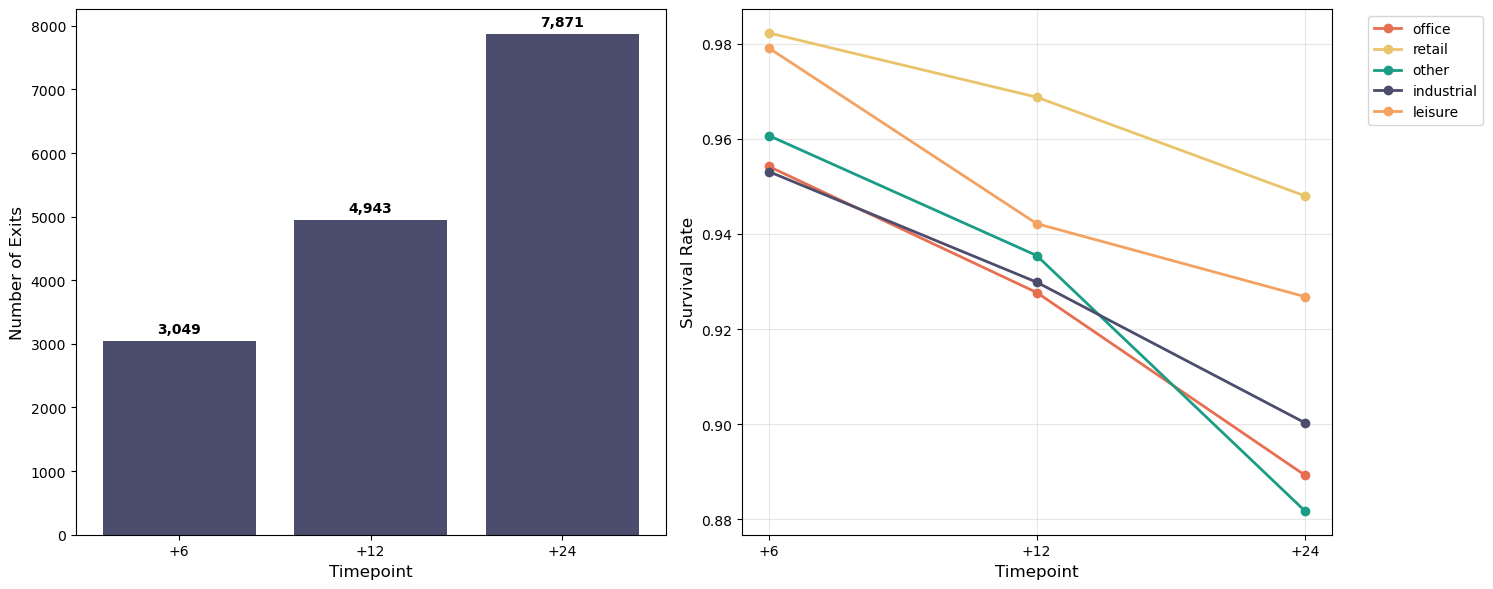

In [81]:
def analyze_exit_patterns_selected(df, survival_timepoints=['+6', '+12', '+24']):
    """
    Create selected visualizations: Business Exit Counts and Survival Rates by Industry
    """
    
    # Create survival indicators
    baseline_businesses = set(df[df['timepoint'] == '0']['uarn'].unique())
    
    exit_analysis = {}
    
    for tp in survival_timepoints:
        surviving_businesses = set(df[df['timepoint'] == tp]['uarn'].unique())
        exited_businesses = baseline_businesses - surviving_businesses
        
        survival_rate = len(surviving_businesses) / len(baseline_businesses)
        exit_rate = len(exited_businesses) / len(baseline_businesses)
        
        exit_analysis[tp] = {
            'survival_count': len(surviving_businesses),
            'exit_count': len(exited_businesses),
            'survival_rate': survival_rate,
            'exit_rate': exit_rate
        }
    
    # Industry-specific exit patterns
    baseline_df = df[df['timepoint'] == '0'].copy()
    industry_exit = {}
    
    for industry in baseline_df['category_group'].dropna().unique():
        industry_businesses = set(baseline_df[baseline_df['category_group'] == industry]['uarn'].unique())
        
        industry_exit[industry] = {}
        for tp in survival_timepoints:
            surviving = set(df[df['timepoint'] == tp]['uarn'].unique())
            industry_surviving = industry_businesses & surviving
            
            if len(industry_businesses) > 0:
                industry_exit[industry][tp] = {
                    'survival_rate': len(industry_surviving) / len(industry_businesses),
                    'exit_rate': 1 - (len(industry_surviving) / len(industry_businesses))
                }
    
    # Create visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Business Exit Counts by Timepoint
    timepoints = list(exit_analysis.keys())
    exit_counts = [exit_analysis[tp]['exit_count'] for tp in timepoints]
    bars = ax1.bar(timepoints, exit_counts, color='#4c4c6d')
    #ax1.set_title('Business Exit Counts by Timepoint', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Timepoint', fontsize=12)
    ax1.set_ylabel('Number of Exits', fontsize=12)
    
    # Add value labels
    for bar, count in zip(bars, exit_counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(exit_counts)*0.01,
                f'{count:,}', ha='center', va='bottom', fontweight='bold')
    
    # Survival Rates by Industry
    industry_survival_df = pd.DataFrame({
        industry: {tp: industry_exit[industry][tp]['survival_rate'] 
                  for tp in survival_timepoints if tp in industry_exit[industry]}
        for industry in industry_exit.keys()
    })
    
    colors = ['#e76f51', '#e9c46a', '#1b9c85', '#4c4c6d', '#f4a261']
    
    for i, industry in enumerate(industry_survival_df.columns):
        if not industry_survival_df[industry].isna().all():
            color = colors[i % len(colors)]
            ax2.plot(industry_survival_df.index, industry_survival_df[industry], 
                    'o-', label=industry, linewidth=2, color=color, markersize=6)
    
    #ax2.set_title('Survival Rates by Industry', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Timepoint', fontsize=12)
    ax2.set_ylabel('Survival Rate', fontsize=12)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    #plt.savefig('exit_patterns_selected.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return exit_analysis, industry_exit

# usage
exit_analysis, industry_exit = analyze_exit_patterns_selected(data_2017)

# Dynamic Bunching Analysis

In [82]:
def single_bunching_analysis(df, thresholds=[15000], window=500):
    results = []
    
    if len(df) == 0:
        return pd.DataFrame()
        
    df_clean = df[df['rateable_value'].notna()]
    
    for threshold in thresholds:
        before = len(df_clean[(df_clean['rateable_value'] >= threshold-window) & 
                             (df_clean['rateable_value'] < threshold)])
        after = len(df_clean[(df_clean['rateable_value'] >= threshold) & 
                            (df_clean['rateable_value'] <= threshold+window)])
        
        ratio = before / max(after, 1)
        distortion = (ratio - 1) * 100
        
        results.append({
            'threshold': threshold,
            'before_count': before,
            'after_count': after,
            'ratio': ratio,
            'distortion_pct': distortion
        })
    
    return pd.DataFrame(results)

dynamic_2017 = single_bunching_analysis(data_2017)

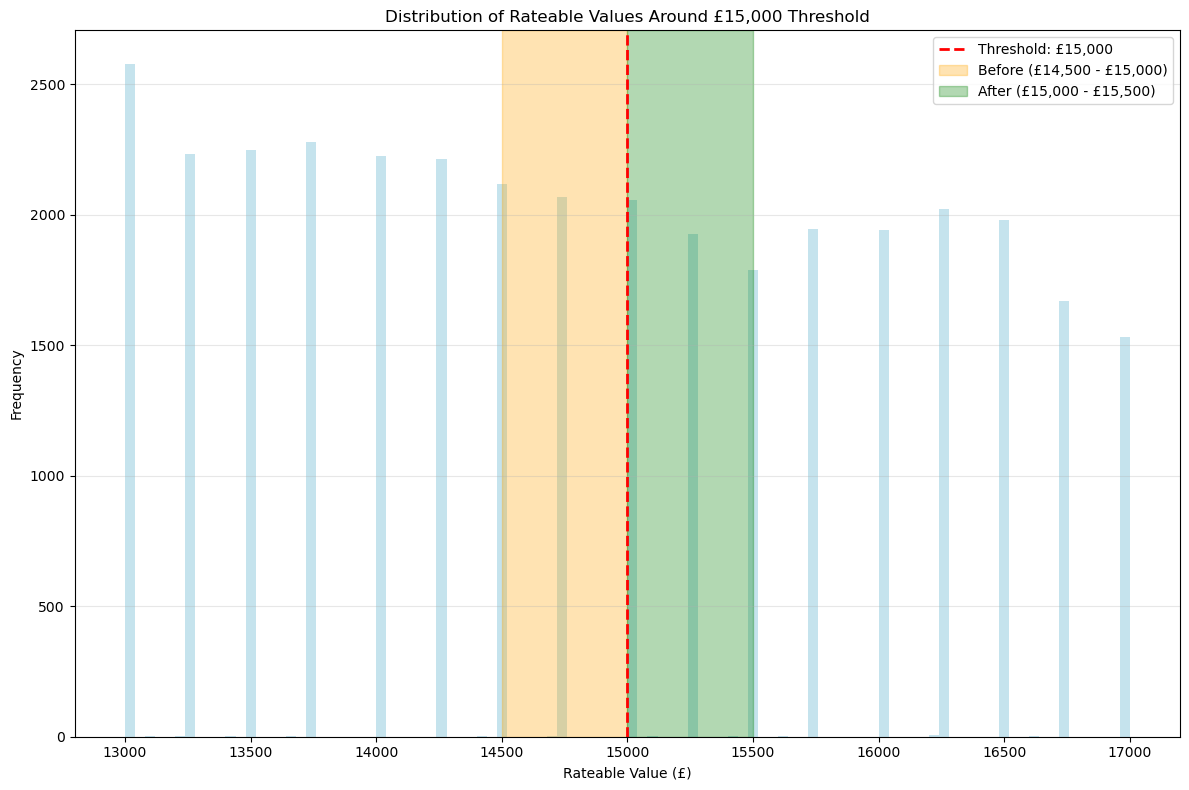

In [83]:
plt.figure(figsize=(12, 8))

# 创建rateable_value的直方图，突出显示threshold区域
df_clean = data_2017[data_2017['rateable_value'].notna()]

threshold = 15000  # 或者使用dynamic_2017['threshold'].iloc[0]
window = 500

plt.hist(df_clean['rateable_value'], bins=100, alpha=0.7, color='lightblue', 
         range=(threshold-2000, threshold+2000))

# 突出显示threshold前后的区域
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: £{threshold:,}')
plt.axvspan(threshold-window, threshold, alpha=0.3, color='orange', label=f'Before (£{threshold-window:,} - £{threshold:,})')
plt.axvspan(threshold, threshold+window, alpha=0.3, color='green', label=f'After (£{threshold:,} - £{threshold+window:,})')

plt.xlabel('Rateable Value (£)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Rateable Values Around £{threshold:,} Threshold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
def analyze_bunching_by_borough_timepoint(data_2017, thresholds=[15000], window=500):
    """
    Analyze bunching effect by borough and timepoint
    
    Parameters:
    data_2017: DataFrame with columns including 'borough', 'timepoint', 'rateable_value'
    thresholds: list of threshold values to analyze
    window: window size around threshold
    
    Returns:
    DataFrame with bunching distortion by borough and timepoint
    """
    
    # Create timepoint mapping for proper ordering
    timepoint_mapping = {
    '-12': 'pre_12m',
    '-6': 'pre_6m', 
    '0': 'revaluation',
    '+6': 'post_6m',
    '+12': 'post_12m',
    '+24': 'post_24m',
    'other': 'other'
}
    
    results = []
    
    # Get unique boroughs and timepoints
    boroughs = data_2017['borough'].unique()
    timepoints = sorted(data_2017['timepoint'].unique())
    
    for borough in boroughs:
        for timepoint in timepoints:
            # Filter data for this borough and timepoint
            subset = data_2017[(data_2017['borough'] == borough) & 
                              (data_2017['timepoint'] == timepoint)]
            
            if len(subset) == 0:
                continue
                
            # Clean data
            subset_clean = subset[subset['rateable_value'].notna()]
            
            if len(subset_clean) == 0:
                continue
            
            for threshold in thresholds:
                # Count observations before and after threshold
                before = len(subset_clean[
                    (subset_clean['rateable_value'] >= threshold - window) & 
                    (subset_clean['rateable_value'] < threshold)
                ])
                
                after = len(subset_clean[
                    (subset_clean['rateable_value'] >= threshold) & 
                    (subset_clean['rateable_value'] <= threshold + window)
                ])
                
                # Calculate bunching distortion
                ratio = before / max(after, 1)
                distortion = (ratio - 1) * 100
                
                # Map timepoint to period name
                period_name = timepoint_mapping.get(timepoint, f'timepoint_{timepoint}')
                
                results.append({
                    'Borough': borough,
                    'timepoint': timepoint,
                    'period': period_name,
                    'threshold': threshold,
                    'before_count': before,
                    'after_count': after,
                    'ratio': ratio,
                    'distortion_pct': distortion
                })
    
    return pd.DataFrame(results)

In [85]:
analyze_bunching_by_borough_timepoint(data_2017)

,Borough,timepoint,period,threshold,before_count,after_count,ratio,distortion_pct
0,City of London,+12,post_12m,15000,151,174,0.867816,-13.218391
1,City of London,+24,post_24m,15000,151,189,0.798942,-20.105820
2,City of London,+6,post_6m,15000,145,163,0.889571,-11.042945
3,City of London,-12,pre_12m,15000,126,200,0.630000,-37.000000
4,City of London,-6,pre_6m,15000,126,200,0.630000,-37.000000
5,City of London,0,revaluation,15000,145,159,0.911950,-8.805031
6,Camden,+12,post_12m,15000,150,209,0.717703,-28.229665
7,Camden,+24,post_24m,15000,155,209,0.741627,-25.837321
8,Camden,+6,post_6m,15000,149,209,0.712919,-28.708134
9,Camden,-12,pre_12m,15000,159,232,0.685345,-31.465517


Analyzing bunching effects...

Creating pivot table...
Bunching Distortion by Borough:
period          pre_12m  pre_6m  revaluation  post_6m  post_12m  post_24m
Borough                                                                  
Camden            -31.5   -31.5        -31.0    -28.7     -28.2     -25.8
City of London    -37.0   -37.0         -8.8    -11.0     -13.2     -20.1
Hackney           -29.9   -29.5        -43.9    -41.0     -43.6     -48.1
Westminster       -18.6   -18.6        -23.2    -25.3     -26.0     -25.7

Generating visualizations...
1. Creating line chart...


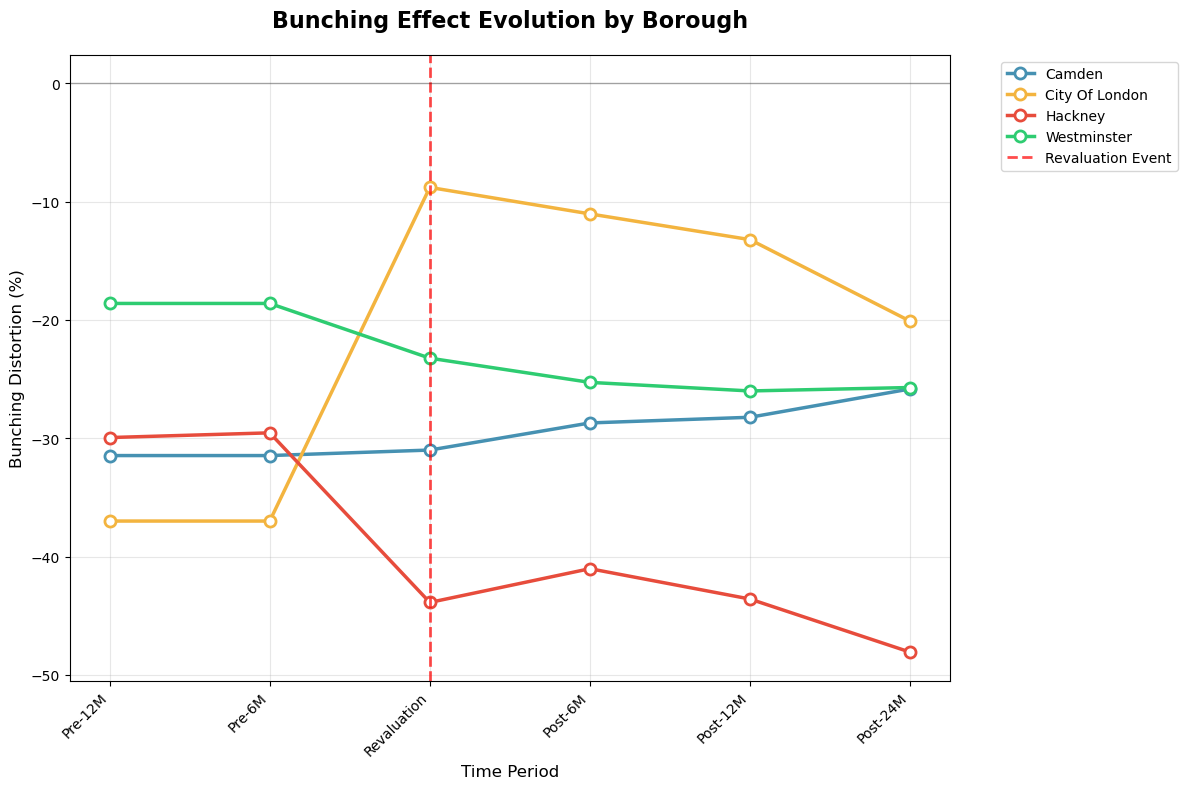

2. Creating heatmap...


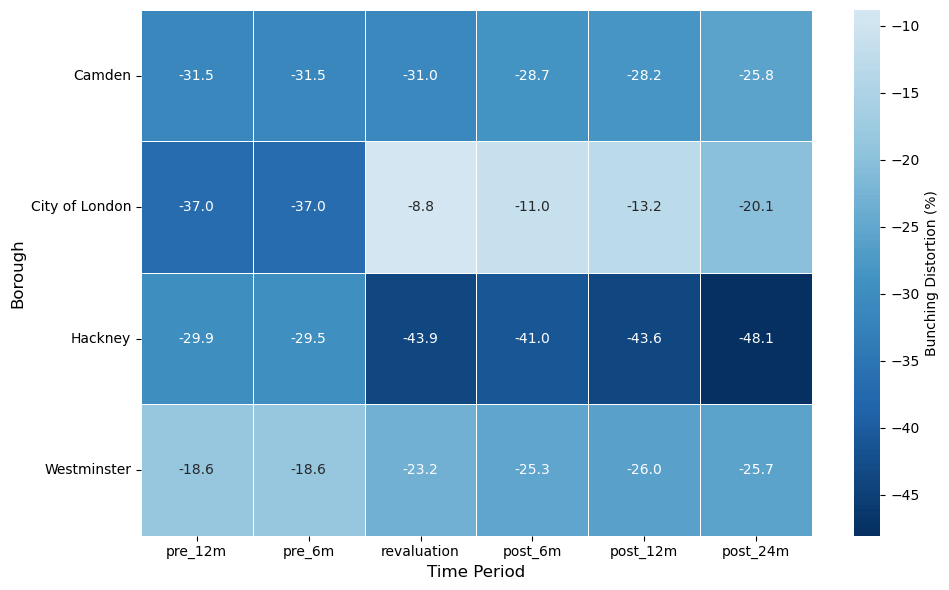

3. Creating individual borough plots...


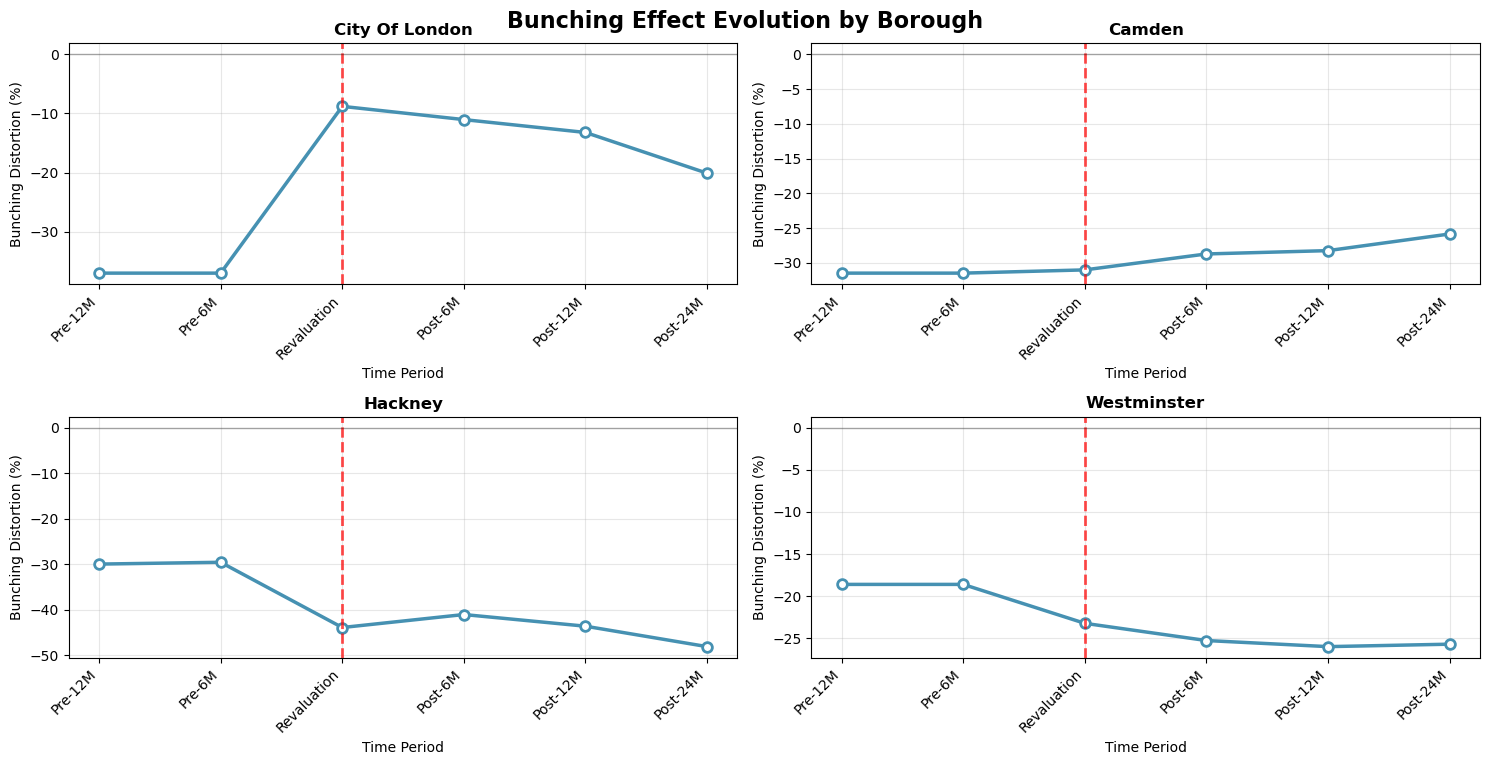

In [86]:
def create_bunching_pivot_table(bunching_results):
    """Create pivot table showing distortion by borough and period"""
    pivot_table = bunching_results.pivot_table(
        values='distortion_pct', 
        index='Borough', 
        columns='period',
        aggfunc='mean'
    )
    
    # Reorder columns in logical time sequence
    period_order = ['pre_12m', 'pre_6m', 'revaluation', 'post_6m', 'post_12m', 'post_24m']
    available_periods = [p for p in period_order if p in pivot_table.columns]
    pivot_table = pivot_table[available_periods]
    
    return pivot_table

def plot_bunching_evolution_line_chart(bunching_results):
    """Create line chart showing bunching evolution over time"""
    
    # Prepare data
    pivot_data = create_bunching_pivot_table(bunching_results)
    
    plt.figure(figsize=(12, 8))
    
    # Define colors for each borough
    colors = ['#4691B2', '#F3B43F', '#E74C3C', '#2ECC71']
    
    # Plot line for each borough
    for i, (borough, row) in enumerate(pivot_data.iterrows()):
        plt.plot(range(len(row)), row.values, 
                marker='o', linewidth=2.5, markersize=8,
                color=colors[i % len(colors)], 
                label=borough.replace('_', ' ').title(),
                markerfacecolor='white',
                markeredgewidth=2,
                markeredgecolor=colors[i % len(colors)])
    
    # Add vertical line at revaluation
    revaluation_idx = None
    if 'revaluation' in pivot_data.columns:
        revaluation_idx = list(pivot_data.columns).index('revaluation')
        plt.axvline(x=revaluation_idx, color='red', linestyle='--', 
                   alpha=0.7, linewidth=2, label='Revaluation Event')
    
    # Add horizontal line at zero
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    
    # Formatting
    plt.title('Bunching Effect Evolution by Borough', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Time Period', fontsize=12)
    plt.ylabel('Bunching Distortion (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Set x-axis labels
    period_labels = [col.replace('_', '-').title() for col in pivot_data.columns]
    plt.xticks(range(len(period_labels)), period_labels, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return pivot_data

def plot_bunching_heatmap(bunching_results):
    """Create heatmap showing bunching distortion"""
    
    pivot_data = create_bunching_pivot_table(bunching_results)
    
    plt.figure(figsize=(10, 6))
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.1f', 
                cmap='RdBu_r',
                center=0,
                cbar_kws={'label': 'Bunching Distortion (%)'},
                linewidths=0.5)
    
    #plt.title('Bunching Distortion Heatmap by Borough and Time Period', 
    #          fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Time Period', fontsize=12)
    plt.ylabel('Borough', fontsize=12)
    
    # Format y-axis labels
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    #plt.savefig('bunching_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pivot_data

def plot_bunching_subplots(bunching_results):
    """Create subplot for each borough"""
    
    boroughs = bunching_results['Borough'].unique()
    
    # Calculate subplot layout
    n_boroughs = len(boroughs)
    if n_boroughs <= 4:
        rows, cols = 2, 2
    else:
        rows = int(np.ceil(n_boroughs / 2))
        cols = 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Period order for consistent x-axis
    period_order = ['pre_12m', 'pre_6m', 'revaluation', 'post_6m', 'post_12m', 'post_24m']
    
    for i, borough in enumerate(boroughs):
        if i >= len(axes):
            break
            
        ax = axes[i]
        borough_data = bunching_results[bunching_results['Borough'] == borough]
        
        # Order data by periods
        ordered_data = []
        ordered_labels = []
        
        for period in period_order:
            period_data = borough_data[borough_data['period'] == period]
            if len(period_data) > 0:
                ordered_data.append(period_data['distortion_pct'].iloc[0])
                ordered_labels.append(period)
        
        if ordered_data:
            # Plot line
            ax.plot(range(len(ordered_data)), ordered_data,
                   marker='o', linewidth=2.5, markersize=7,
                   color='#4691B2',
                   markerfacecolor='white',
                   markeredgewidth=2,
                   markeredgecolor='#4691B2')
            
            # Add vertical line at revaluation
            if 'revaluation' in ordered_labels:
                revaluation_idx = ordered_labels.index('revaluation')
                ax.axvline(x=revaluation_idx, color='red', linestyle='--', 
                          alpha=0.7, linewidth=2)
        
        # Add horizontal line at zero
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        
        # Formatting
        ax.set_title(f'{borough.replace("_", " ").title()}', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Time Period', fontsize=10)
        ax.set_ylabel('Bunching Distortion (%)', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Set x-axis
        if ordered_labels:
            ax.set_xticks(range(len(ordered_labels)))
            ax.set_xticklabels([label.replace('_', '-').title() for label in ordered_labels], 
                              rotation=45, ha='right')
    
    # Hide empty subplots
    for i in range(len(boroughs), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Bunching Effect Evolution by Borough', 
                 fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()

# Main analysis function
def analyze_and_visualize_bunching(data_2017, thresholds=[15000], window=500):
    """
    Complete analysis and visualization of bunching effects
    
    Parameters:
    data_2017: DataFrame with borough, timepoint, and rateable_value columns
    thresholds: list of thresholds to analyze
    window: window size around threshold
    """
    
    print("Analyzing bunching effects...")
    bunching_results = analyze_bunching_by_borough_timepoint(data_2017, thresholds, window)
    
    if len(bunching_results) == 0:
        print("No bunching results found. Please check your data.")
        return None
    
    print("\nCreating pivot table...")
    pivot_table = create_bunching_pivot_table(bunching_results)
    print("Bunching Distortion by Borough:")
    print(pivot_table.round(1))
    
    print("\nGenerating visualizations...")
    
    # 1. Line chart
    print("1. Creating line chart...")
    plot_bunching_evolution_line_chart(bunching_results)
    
    # 2. Heatmap
    print("2. Creating heatmap...")
    plot_bunching_heatmap(bunching_results)
    
    # 3. Subplots
    print("3. Creating individual borough plots...")
    plot_bunching_subplots(bunching_results)
    
    return bunching_results, pivot_table

# 运行完整分析（推荐）
bunching_results, pivot_table = analyze_and_visualize_bunching(data_2017)


# Create only the line chart
#pivot_table = plot_bunching_evolution_line_chart(bunching_results)

# Create only the heatmap
#plot_bunching_heatmap(bunching_results)

# Create only the subplots
#plot_bunching_subplots(bunching_results)

In [87]:
dynamic_camden_17=single_bunching_analysis(camden_17N)
dynamic_citylondon_17=single_bunching_analysis(citylondon_17N)
dynamic_hackney_17=single_bunching_analysis(hackney_17N)
dynamic_westminster_17=single_bunching_analysis(westminster_17N)

dynamic_camden_17.head()

,threshold,before_count,after_count,ratio,distortion_pct
0,15000,1059,1500,0.706,-29.4


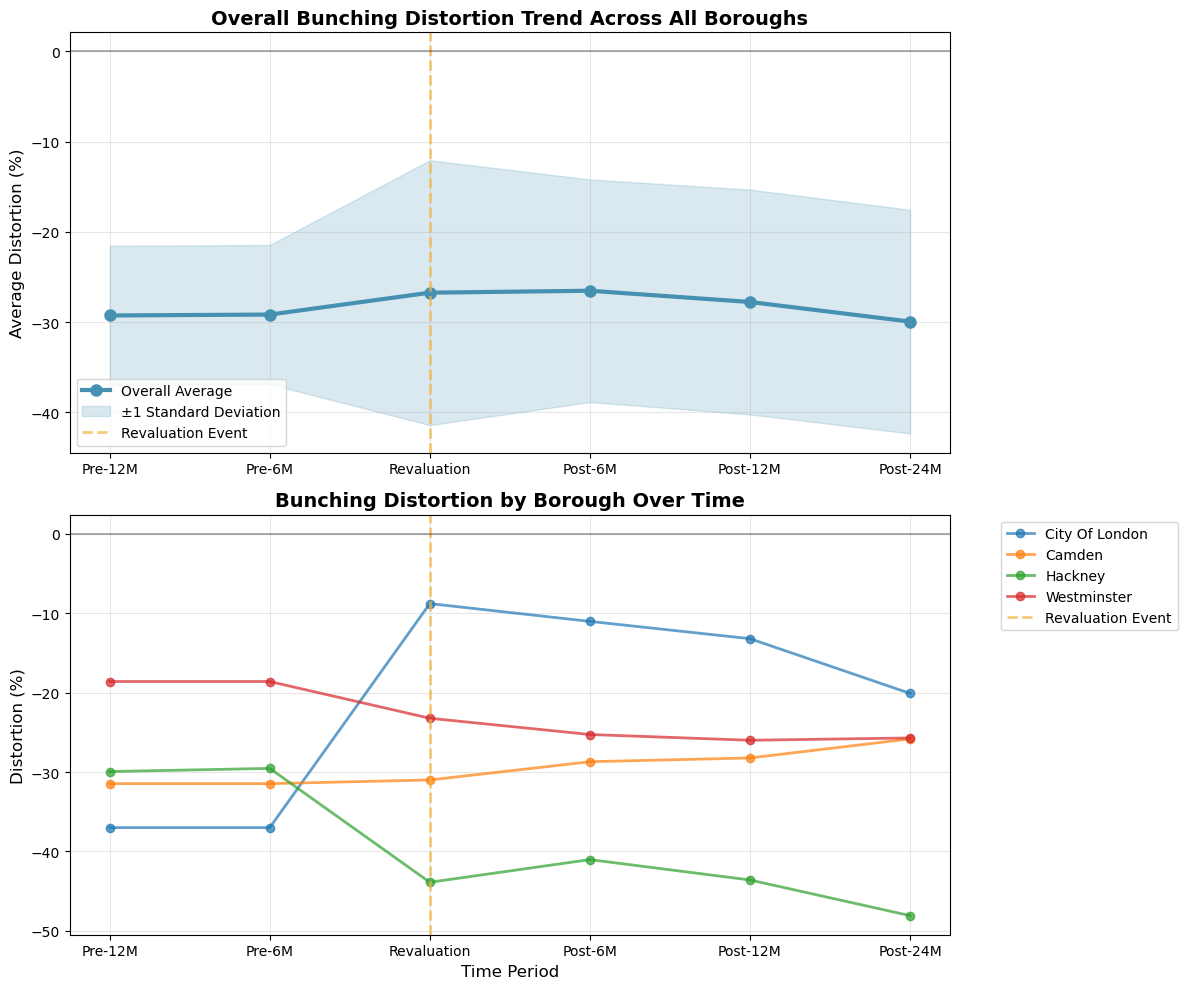

Overall Time Trend Summary:
        period       mean        std
3      pre_12m -29.254860   7.716918
4       pre_6m -29.155348   7.707639
5  revaluation -26.729469  14.671842
2      post_6m -26.514405  12.332559
0     post_12m -27.760790  12.454431
1     post_24m -29.933587  12.387461


In [91]:
def plot_overall_time_trend(bunching_results):
    """绘制整体时间变化趋势"""
    
    # 计算每个时间点的平均distortion
    time_trend = bunching_results.groupby('period')['distortion_pct'].agg(['mean', 'std']).reset_index()
    
    # 排序时间点
    period_order = ['pre_12m', 'pre_6m', 'revaluation', 'post_6m', 'post_12m', 'post_24m']
    time_trend['period'] = pd.Categorical(time_trend['period'], categories=period_order, ordered=True)
    time_trend = time_trend.sort_values('period')
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # 上图：平均趋势线
    x_pos = range(len(time_trend))
    ax1.plot(x_pos, time_trend['mean'], marker='o', linewidth=3, markersize=8,
             color='#4691B2', markerfacecolor='#4691B2', label='Overall Average')
    
    # 添加误差带
    ax1.fill_between(x_pos, 
                     time_trend['mean'] - time_trend['std'], 
                     time_trend['mean'] + time_trend['std'],
                     alpha=0.2, color='#4691B2', label='±1 Standard Deviation')
    
    # revaluation线
    if 'revaluation' in time_trend['period'].values:
        revaluation_idx = list(time_trend['period']).index('revaluation')
        ax1.axvline(x=revaluation_idx, color='#F3B43F', linestyle='--', 
                   alpha=0.7, linewidth=2, label='Revaluation Event')
    
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax1.set_title('Overall Bunching Distortion Trend Across All Boroughs', 
                  fontsize=14, fontweight='bold')
    ax1.set_ylabel('Average Distortion (%)', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([p.replace('_', '-').title() for p in time_trend['period']])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 下图：各区域的时间趋势
    for borough in bunching_results['Borough'].unique():
        borough_data = bunching_results[bunching_results['Borough'] == borough]
        borough_trend = borough_data.groupby('period')['distortion_pct'].mean().reset_index()
        borough_trend['period'] = pd.Categorical(borough_trend['period'], categories=period_order, ordered=True)
        borough_trend = borough_trend.sort_values('period')
        
        x_pos_borough = range(len(borough_trend))
        ax2.plot(x_pos_borough, borough_trend['distortion_pct'], 
                marker='o', linewidth=2, markersize=6,
                label=borough.replace('_', ' ').title(), alpha=0.7)
    
    # revaluation线
    if 'revaluation' in period_order:
        revaluation_idx = period_order.index('revaluation')
        ax2.axvline(x=revaluation_idx, color='#F3B43F', linestyle='--', 
                   alpha=0.7, linewidth=2, label='Revaluation Event')
    
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.set_title('Bunching Distortion by Borough Over Time', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time Period', fontsize=12)
    ax2.set_ylabel('Distortion (%)', fontsize=12)
    ax2.set_xticks(range(len(period_order)))
    ax2.set_xticklabels([p.replace('_', '-').title() for p in period_order])
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return time_trend

# 运行时间趋势分析
time_trend = plot_overall_time_trend(bunching_results)
print("Overall Time Trend Summary:")
print(time_trend)

In [90]:
def analyze_time_changes(bunching_results):
    """Analyze the statistical significance of the time variation"""
    
    # Calculate the changes before and after revaluation
    pre_revaluation = bunching_results[bunching_results['period'].isin(['pre_12m', 'pre_6m'])]
    post_revaluation = bunching_results[bunching_results['period'].isin(['post_6m', 'post_12m', 'post_24m'])]
    revaluation = bunching_results[bunching_results['period'] == 'revaluation']
    
    print("=== Time Change Analysis ===")
    print(f"Pre-revaluation average distortion: {pre_revaluation['distortion_pct'].mean():.1f}%")
    print(f"Revaluation distortion: {revaluation['distortion_pct'].mean():.1f}%")
    print(f"Post-revaluation average distortion: {post_revaluation['distortion_pct'].mean():.1f}%")
    print()
    
    # The changes in each region
    print("=== Borough-specific Changes ===")
    for borough in bunching_results['Borough'].unique():
        borough_data = bunching_results[bunching_results['Borough'] == borough]
        
        pre = borough_data[borough_data['period'].isin(['pre_12m', 'pre_6m'])]['distortion_pct'].mean()
        during = borough_data[borough_data['period'] == 'revaluation']['distortion_pct'].values
        post = borough_data[borough_data['period'].isin(['post_6m', 'post_12m', 'post_24m'])]['distortion_pct'].mean()
        
        during_val = during[0] if len(during) > 0 else 'N/A'
        
        print(f"{borough.replace('_', ' ').title()}:")
        print(f"  Pre → During → Post: {pre:.1f}% → {during_val} → {post:.1f}%")
        if isinstance(during_val, (int, float)):
            print(f"  Change (Pre→During): {during_val - pre:.1f} percentage points")
            print(f"  Change (During→Post): {post - during_val:.1f} percentage points")
        print()


analyze_time_changes(bunching_results)

=== Time Change Analysis ===
Pre-revaluation average distortion: -29.2%
Revaluation distortion: -26.7%
Post-revaluation average distortion: -28.1%

=== Borough-specific Changes ===
City Of London:
  Pre → During → Post: -37.0% → -8.805031446540879 → -14.8%
  Change (Pre→During): 28.2 percentage points
  Change (During→Post): -6.0 percentage points

Camden:
  Pre → During → Post: -31.5% → -31.000000000000007 → -27.6%
  Change (Pre→During): 0.5 percentage points
  Change (During→Post): 3.4 percentage points

Hackney:
  Pre → During → Post: -29.7% → -43.87755102040817 → -44.2%
  Change (Pre→During): -14.1 percentage points
  Change (During→Post): -0.4 percentage points

Westminster:
  Pre → During → Post: -18.6% → -23.235294117647054 → -25.7%
  Change (Pre→During): -4.6 percentage points
  Change (During→Post): -2.4 percentage points



## Analyze business response strategies by periods

In [94]:
def analyze_business_responses(df):
    """Analyze business response strategies with refined classification standards"""
    
    # Add +24 timepoint
    baseline = df[df['timepoint'] == '-12'].dropna(subset=['rateable_value'])
    revaluation = df[df['timepoint'] == '0'].dropna(subset=['rateable_value'])
    post_6m = df[df['timepoint'] == '+6'].dropna(subset=['rateable_value'])
    post_12m = df[df['timepoint'] == '+12'].dropna(subset=['rateable_value'])
    post_24m = df[df['timepoint'] == '+24'].dropna(subset=['rateable_value'])  # Add this
    
    # Index the dataframes
    baseline_indexed = baseline.set_index('uarn')[['rateable_value', 'total_floor_area','category_group', 'borough']]
    revaluation_indexed = revaluation.set_index('uarn')[['rateable_value', 'total_floor_area']]
    post_6m_indexed = post_6m.set_index('uarn')[['rateable_value', 'total_floor_area']]
    post_12m_indexed = post_12m.set_index('uarn')[['rateable_value', 'total_floor_area']]
    post_24m_indexed = post_24m.set_index('uarn')[['rateable_value', 'total_floor_area']]  # Add this
    
    # Fix the classify_strategy function
    def classify_strategy(base_val, reval_val, post_val, base_area, post_area, category, period):
        strategies = []
        
        # 1. Successful Appeal: < 85% of revaluation value
        if post_val < reval_val * 0.85:
            strategies.append('successful_appeal')
        
        # 2. Space Reduction (relaxed conditions)
        if category == 'RETAIL':
        # Retail: >20% area decrease
            if post_area < base_area * 0.8:  # >20% decrease
                strategies.append('space_reduction')
        else:
                # Non-retail: >15% increase in RV per square foot (density increase)
                base_density = base_val / base_area if base_area > 0 else 0
                post_density = post_val / post_area if post_area > 0 else 0
                
                if base_density > 0 and post_density / base_density > 1.15:  # >15% density increase
                    strategies.append('space_reduction')
        
        # 3. Acceptance: ±15% value change (relaxed from 10%)
        value_change_pct = abs(post_val - reval_val) / reval_val
        if value_change_pct <= 0.15:
            strategies.append('acceptance')
        
        # Return strategy
        if len(strategies) >= 2:
            return 'mixed_strategy'
        elif len(strategies) == 1:
            return strategies[0]
        else:
            return 'unknown'
    
    # Analyze all three periods
    all_responses = []
    
    def analyze_period(common_uarns, post_indexed, period_name):
        responses = []
        for uarn in common_uarns:
            # ... [keep existing logic] ...
            responses.append({
                'uarn': uarn,
                'period': period_name,
                'borough': baseline_indexed.loc[uarn, 'borough'],
                'baseline_value': baseline_indexed.loc[uarn, 'rateable_value'],
                'revaluation_value': revaluation_indexed.loc[uarn, 'rateable_value'],
                'post_value': post_indexed.loc[uarn, 'rateable_value'],
                'baseline_area': baseline_indexed.loc[uarn, 'total_floor_area'],
                'post_area': post_indexed.loc[uarn, 'total_floor_area'],
                'strategy': classify_strategy(baseline_indexed.loc[uarn, 'rateable_value'], 
                                            revaluation_indexed.loc[uarn, 'rateable_value'],
                                            post_indexed.loc[uarn, 'rateable_value'],
                                            baseline_indexed.loc[uarn, 'total_floor_area'],
                                            post_indexed.loc[uarn, 'total_floor_area'],
                                            baseline_indexed.loc[uarn, 'category_group'], 
                                            period_name),
                'affected_15k_threshold': baseline_indexed.loc[uarn, 'rateable_value'] < 15000 and revaluation_indexed.loc[uarn, 'rateable_value'] >= 15000,
                'category_group': baseline_indexed.loc[uarn, 'category_group']
            })
        return responses
    
    # Analyze all periods
    for post_data, period in [(post_6m_indexed, '+6'), (post_12m_indexed, '+12'), (post_24m_indexed, '+24')]:
        common = set(baseline_indexed.index) & set(revaluation_indexed.index) & set(post_data.index)
        all_responses.extend(analyze_period(common, post_data, period))
    
    df_result = pd.DataFrame(all_responses)
    
    # Identify delayed responses: no change at +6 but change at +12 or +24
    if len(df_result) > 0:
        pivot = df_result.pivot_table(index='uarn', columns='period', values='strategy', aggfunc='first')
    
    # Delayed response: acceptance at +6 but active strategy at +12 or +24
        delayed_mask = (
            (pivot['+6'] == 'acceptance') & 
            ((pivot['+12'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy'])) |
             (pivot['+24'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy'])))
        )
        
        delayed_uarns = pivot[delayed_mask].index
    
    # Mark as delayed_response at the period where active strategy appears
    for period in ['+12', '+24']:
        condition = (
            (df_result['uarn'].isin(delayed_uarns)) & 
            (df_result['period'] == period) &
            (df_result['strategy'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy']))
        )
        df_result.loc[condition, 'strategy'] = 'delayed_response'
        
        
        return df_result

In [113]:
strategy_2017N=analyze_business_responses(data_2017)

In [96]:
strategy_counts = strategy_2017N['strategy'].value_counts()
print(strategy_counts)

strategy
acceptance           135717
delayed_response      46859
mixed_strategy        45413
successful_appeal       296
space_reduction         179
unknown                 131
Name: count, dtype: int64


In [97]:
def analyze_mixed_strategy_composition(response_df):
    """
    Analyze the specific strategy combinations of enterprises in the "mixed_strategy" category  
    
    Parameters:
    response_df: A DataFrame containing the results of the strategy analysis 
    
    Returns:
    dict: Contains the detailed breakdown of the mixed strategy results
    """
    
    def get_individual_strategies(row):
        """Check which strategic conditions are met by a single enterprise"""
        strategies = []
        
        base_val = row['baseline_value']
        reval_val = row['revaluation_value']
        post_val = row['post_value']
        base_area = row['baseline_area']
        post_area = row['post_area']
        category = row['category_group']
        
        # 1. Successful Appeal: < 85% of revaluation value
        if post_val < reval_val * 0.85:
            strategies.append('successful_appeal')
        
        # 2. Space Reduction
        if category == 'RETAIL':
            # Retail: >20% area decrease
            if post_area < base_area * 0.8:
                strategies.append('space_reduction')
        else:
            # Non-retail: >15% density increase
            base_density = base_val / base_area if base_area > 0 else 0
            post_density = post_val / post_area if post_area > 0 else 0
            
            if base_density > 0 and post_density / base_density > 1.15:
                strategies.append('space_reduction')
        
        # 3. Acceptance: ±15% value change
        if reval_val > 0:
            value_change_pct = abs(post_val - reval_val) / reval_val
            if value_change_pct <= 0.15:
                strategies.append('acceptance')
        
        return strategies
    
    # Select the enterprises with mixed strategies
    mixed_strategy_df = response_df[response_df['strategy'] == 'mixed_strategy'].copy()
    
    if len(mixed_strategy_df) == 0:
        print("No businesses with mixed_strategy were found.")
        return {}
    

    mixed_strategy_df['individual_strategies'] = mixed_strategy_df.apply(get_individual_strategies, axis=1)
    mixed_strategy_df['strategy_combination'] = mixed_strategy_df['individual_strategies'].apply(
        lambda x: ' + '.join(sorted(x))
    )
    

    combination_counts = mixed_strategy_df['strategy_combination'].value_counts()
    

    results = {
        'total_mixed_strategy': len(mixed_strategy_df),
        'combination_breakdown': combination_counts.to_dict(),
        'combination_percentages': (combination_counts / len(mixed_strategy_df) * 100).round(2).to_dict(),
        'detailed_data': mixed_strategy_df[['uarn', 'period', 'borough', 'category_group', 
                                          'baseline_value', 'revaluation_value', 'post_value',
                                          'baseline_area', 'post_area', 'strategy_combination']].copy()
    }
    

    print(f"Mixed Strategy is: {results['total_mixed_strategy']}")
    print("\nStrategy Combination Distribution:")
    print("-" * 50)
    
    for combination, count in combination_counts.items():
        percentage = count / len(mixed_strategy_df) * 100
        print(f"{combination}: {count} businesses ({percentage:.1f}%)")
    
    # Analysis by Period
    print("\nAnalysis by Period:")
    print("-" * 50)
    period_analysis = mixed_strategy_df.groupby(['period', 'strategy_combination']).size().unstack(fill_value=0)
    print(period_analysis)
    
    # Analysis by Category
    print("\nAnalysis by Category:")
    print("-" * 50)
    category_analysis = mixed_strategy_df.groupby(['category_group', 'strategy_combination']).size().unstack(fill_value=0)
    print(category_analysis)
    
    return results

mixed_results = analyze_mixed_strategy_composition(strategy_2017N)

Mixed Strategy is: 45413

Strategy Combination Distribution:
--------------------------------------------------
acceptance + space_reduction: 45159 businesses (99.4%)
space_reduction + successful_appeal: 254 businesses (0.6%)

Analysis by Period:
--------------------------------------------------
strategy_combination  acceptance + space_reduction  \
period                                               
+12                                              0   
+24                                          45159   

strategy_combination  space_reduction + successful_appeal  
period                                                     
+12                                                    38  
+24                                                   216  

Analysis by Category:
--------------------------------------------------
strategy_combination  acceptance + space_reduction  \
category_group                                       
industrial                                    2091   
leisure  

In [98]:
# Based on the cross-statistical analysis of "borough" and "strategy"
strategy_borough = strategy_2017N.groupby(['borough', 'strategy']).size().reset_index(name='count')
print("Strategy distribution across boroughs:")
print(strategy_borough)

# Pivot table
pivot_table = strategy_2017N.pivot_table(
    values='post_area',  
    index='borough', 
    columns='strategy', 
    aggfunc='count', 
    fill_value=0
)
print("\nPivot table:")
print(pivot_table)

# Show percentage share of strategies within each borough
percentage_table = strategy_2017N.groupby('borough')['strategy'].value_counts(normalize=True).unstack(fill_value=0) * 100
print("\n各borough内strategy占比(%):")
print(percentage_table.round(1))

# Summarize
print("\nOverall summary:")
print(f"Total records: {len(strategy_2017N)}")
print(f"Number of boroughs: {strategy_2017N['borough'].nunique()}")
print(f"Number of strategy types: {strategy_2017N['strategy'].nunique()}")

Strategy distribution across boroughs:
           borough           strategy  count
0           Camden         acceptance  29490
1           Camden   delayed_response   9920
2           Camden     mixed_strategy   9746
3           Camden    space_reduction     33
4           Camden  successful_appeal     54
5           Camden            unknown     42
6   City of London         acceptance  28237
7   City of London   delayed_response  12718
8   City of London     mixed_strategy  12270
9   City of London    space_reduction     29
10  City of London  successful_appeal     72
11  City of London            unknown     18
12         Hackney         acceptance  13056
13         Hackney   delayed_response   7987
14         Hackney     mixed_strategy   7716
15         Hackney    space_reduction     64
16         Hackney  successful_appeal     29
17         Hackney            unknown     29
18     Westminster         acceptance  64934
19     Westminster   delayed_response  16234
20     Westminst

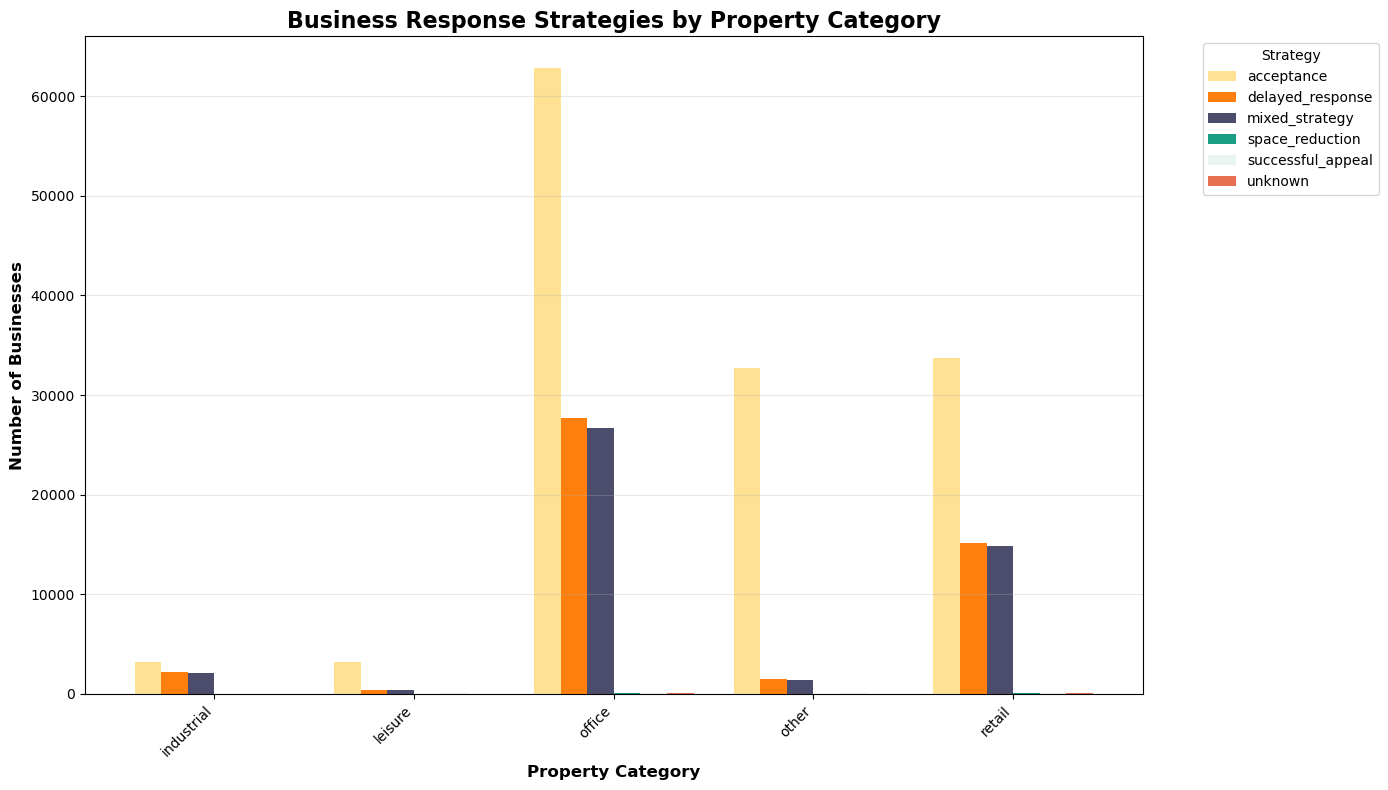

In [101]:
def plot_strategy_by_category(response_df):
    """Bar chart showing the distribution of strategies for each enterprise category"""
    

    strategy_category = pd.crosstab(response_df['category_group'], response_df['strategy'])
    

    plt.figure(figsize=(14, 8))
    colors = {
        'acceptance': '#ffe194',           
        'delayed_response': '#ff7f0e',     
        'mixed_strategy': '#4c4c6d',       
        'space_reduction': '#1b9c85',      
        'successful_appeal': '#e8f6ef',    
        'unknown': '#e76f51'              
    }
    
    available_strategies = [col for col in colors.keys() if col in strategy_category.columns]
    strategy_colors = [colors[strategy] for strategy in available_strategies]
    

    strategy_category[available_strategies].plot(
        kind='bar', 
        color=strategy_colors, 
        width=0.8,
        ax=plt.gca()
    )
    

    plt.title('Business Response Strategies by Property Category', fontsize=16, fontweight='bold')
    plt.xlabel('Property Category', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Businesses', fontsize=12, fontweight='bold')
    plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.show()


plot_strategy_by_category(strategy_2017N)

In [116]:
def analyze_strategy_consistency_and_delay(response_df):
    """
    Analyze the consistency, latency and persistence of the strategies for +6 and +12 months
    """

    # Create Enterprise - Strategy Pivot Table
    strategy_pivot = response_df.pivot_table(
        index='uarn', 
        columns='period', 
        values='strategy', 
        aggfunc='first'
    )


    complete_data = strategy_pivot.dropna(subset=['+6', '+12'])

    # Consistency analysis
    consistency_rate = (complete_data['+6'] == complete_data['+12']).mean() * 100
    consistent_strategies = complete_data.loc[complete_data['+6'] == complete_data['+12'], '+6'].value_counts()

    # Transition matrix
    transition_matrix = pd.crosstab(complete_data['+6'], complete_data['+12'])
    transition_pct = transition_matrix.div(transition_matrix.sum(axis=1), axis=0) * 100

    # Delay pattern analysis
    delay_patterns = (complete_data['+6'] + " → " + complete_data['+12']).value_counts()
    main_delay_pattern = delay_patterns.index[0] if len(delay_patterns) > 0 else "None"
    main_delay_count = delay_patterns.iloc[0] if len(delay_patterns) > 0 else 0
    main_delay_pct = main_delay_count / len(complete_data) * 100

    print(f"Main delay pattern: {main_delay_pattern} ({main_delay_count} firms, {main_delay_pct:.1f}%)")

    # Most stable strategy
    most_stable_strategy = consistent_strategies.index[0] if len(consistent_strategies) > 0 else "None"
    most_stable_count = consistent_strategies.iloc[0] if len(consistent_strategies) > 0 else 0
    print(f"Most stable strategy: {most_stable_strategy} ({most_stable_count} enterprises remained unchanged)")

    results = {
        'total_analyzed': len(complete_data),
        'consistency_rate': consistency_rate,
        'consistent_strategies': consistent_strategies.to_dict(),
        'delay_patterns': delay_patterns.to_dict(),
        'transition_matrix': transition_matrix,
        'transition_percentages': transition_pct,
        'strategy_pivot': complete_data
    }
    
    return results


def visualize_strategy_transitions(results):
    """
    Visualize strategy transitions and delay behaviors
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Strategy consistency pie chart
    consistency_data = ['Consistent', 'Changed']
    consistency_values = [results['consistency_rate'], 100 - results['consistency_rate']]
    
    axes[0,0].pie(consistency_values, labels=consistency_data, autopct='%1.1f%%', startangle=90)
    axes[0,0].set_title('Strategy Consistency (+6 vs +12)')
    
    # 2. Delay behavior distribution
    delay_patterns = results['delay_patterns']
    delay_names = list(delay_patterns.keys())
    delay_counts = list(delay_patterns.values())
    
    axes[0,1].bar(delay_names, delay_counts)
    axes[0,1].set_title('Distribution of Delay Behavior Patterns')
    axes[0,1].set_xticklabels(delay_names, rotation=45, ha='right')
    axes[0,1].set_ylabel('Number of Businesses')
    
    # 3. Transition matrix heatmap
    transition_pct = results['transition_percentages']
    sns.heatmap(transition_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1,0])
    axes[1,0].set_title('Strategy Transition Rates (%) +6 → +12')
    axes[1,0].set_xlabel('Strategy at +12 Months')
    axes[1,0].set_ylabel('Strategy at +6 Months')
    
    # 4. Distribution of consistent strategies
    consistent_strategies = results['consistent_strategies']
    if consistent_strategies:
        axes[1,1].bar(consistent_strategies.keys(), consistent_strategies.values())
        axes[1,1].set_title('Distribution of Consistent Strategies')
        axes[1,1].set_xticklabels(consistent_strategies.keys(), rotation=45, ha='right')
        axes[1,1].set_ylabel('Number of Businesses')
    
    plt.tight_layout()
    plt.show()


consistency_results = analyze_strategy_consistency_and_delay(strategy_2017N)
# visualize_strategy_transitions(consistency_results)

Main delay pattern: acceptance → delayed_response (46859 firms, 61.2%)
Most stable strategy: acceptance (29616 enterprises remained unchanged)


In [120]:
def analyze_strategy_consistency_and_delay(response_df):
    """
    Analyze strategy consistency, delay patterns, and persistence across +6 and +12 months
    
    Parameters:
    response_df: DataFrame containing strategy analysis results
    
    Returns:
    dict: Contains detailed analysis results
    """
    
    # Create business-strategy pivot table
    strategy_pivot = response_df.pivot_table(
        index='uarn', 
        columns='period', 
        values='strategy', 
        aggfunc='first'
    )
    
    available_periods = [col for col in ['+6', '+12', '+24'] if col in strategy_pivot.columns]
    print(f"Available time periods: {available_periods}")
    
    complete_data = strategy_pivot.dropna(subset=['+6', '+12'])
    
    # If +24 data is available, also analyze three-period complete data
    if '+24' in available_periods:
        three_period_data = strategy_pivot.dropna(subset=['+6', '+12', '+24'])
        print(f"Complete three-period data firms: {len(three_period_data)}")
    else:
        three_period_data = pd.DataFrame()
    
    if len(complete_data) == 0:
        print("No firms with both +6 and +12 month data")
        return {}
    
    print(f"Two-period analysis total firms: {len(complete_data)}")
    
    # 1. Strategy consistency analysis
    print("\n=== Strategy Consistency Analysis ===")
    consistent_mask = complete_data['+6'] == complete_data['+12']
    consistent_count = consistent_mask.sum()
    consistency_rate = consistent_count / len(complete_data) * 100
    
    print(f"Firms maintaining consistent strategy: {consistent_count} ({consistency_rate:.1f}%)")
    print(f"Firms changing strategy: {len(complete_data) - consistent_count} ({100 - consistency_rate:.1f}%)")
    
    # Distribution of consistent strategies
    consistent_strategies = complete_data[consistent_mask]['+6'].value_counts()
    print("\nConsistent strategy distribution:")
    for strategy, count in consistent_strategies.items():
        pct = count / consistent_count * 100
        print(f"  {strategy}: {count} firms ({pct:.1f}%)")
    
    # 2. Delayed behavior analysis (+6 → +12)
    print("\n=== Delayed Behavior Analysis (+6 → +12) ===")
    
    # Define delay patterns: +6 month acceptance, +12 month active strategy
    delay_patterns_12 = {
        'acceptance_to_appeal': (complete_data['+6'] == 'acceptance') & 
                               (complete_data['+12'] == 'successful_appeal'),
        'acceptance_to_space': (complete_data['+6'] == 'acceptance') & 
                              (complete_data['+12'] == 'space_reduction'),
        'acceptance_to_mixed': (complete_data['+6'] == 'acceptance') & 
                              (complete_data['+12'] == 'mixed_strategy'),
        'acceptance_to_delayed': (complete_data['+6'] == 'acceptance') & 
                                (complete_data['+12'] == 'delayed_response')
    }
    
    total_delayed_12 = 0
    print("Delayed behavior patterns (+6 → +12):")
    for pattern_name, pattern_mask in delay_patterns_12.items():
        count = pattern_mask.sum()
        total_delayed_12 += count
        if count > 0:
            pct = count / len(complete_data) * 100
            print(f"  {pattern_name}: {count} firms ({pct:.1f}%)")
    
    delay_rate_12 = total_delayed_12 / len(complete_data) * 100
    print(f"\nTotal delayed behavior rate (+6 → +12): {total_delayed_12} firms ({delay_rate_12:.1f}%)")
    
    # If +24 data exists, analyze +6 → +24 and +12 → +24 delays
    delay_patterns_24 = {}
    delay_patterns_12_24 = {}
    total_delayed_24 = 0
    total_delayed_12_24 = 0
    
    if '+24' in available_periods and len(three_period_data) > 0:
        print("\n=== Delayed Behavior Analysis (+6 → +24) ===")
        
        # +6 → +24 delay patterns
        delay_patterns_24 = {
            'acceptance_to_appeal_24': (three_period_data['+6'] == 'acceptance') & 
                                      (three_period_data['+24'] == 'successful_appeal'),
            'acceptance_to_space_24': (three_period_data['+6'] == 'acceptance') & 
                                     (three_period_data['+24'] == 'space_reduction'),
            'acceptance_to_mixed_24': (three_period_data['+6'] == 'acceptance') & 
                                     (three_period_data['+24'] == 'mixed_strategy'),
            'acceptance_to_delayed_24': (three_period_data['+6'] == 'acceptance') & 
                                       (three_period_data['+24'] == 'delayed_response')
        }
        
        print("Delayed behavior patterns (+6 → +24):")
        for pattern_name, pattern_mask in delay_patterns_24.items():
            count = pattern_mask.sum()
            total_delayed_24 += count
            if count > 0:
                pct = count / len(three_period_data) * 100
                print(f"  {pattern_name}: {count} firms ({pct:.1f}%)")
        
        delay_rate_24 = total_delayed_24 / len(three_period_data) * 100
        print(f"\nTotal delayed behavior rate (+6 → +24): {total_delayed_24} firms ({delay_rate_24:.1f}%)")
        
        print("\n=== Delayed Behavior Analysis (+12 → +24) ===")
        
        # +12 → +24 delay patterns
        delay_patterns_12_24 = {
            'acceptance_to_appeal_12_24': (three_period_data['+12'] == 'acceptance') & 
                                         (three_period_data['+24'] == 'successful_appeal'),
            'acceptance_to_space_12_24': (three_period_data['+12'] == 'acceptance') & 
                                        (three_period_data['+24'] == 'space_reduction'),
            'acceptance_to_mixed_12_24': (three_period_data['+12'] == 'acceptance') & 
                                        (three_period_data['+24'] == 'mixed_strategy'),
            'acceptance_to_delayed_12_24': (three_period_data['+12'] == 'acceptance') & 
                                          (three_period_data['+24'] == 'delayed_response')
        }
        
        print("Delayed behavior patterns (+12 → +24):")
        for pattern_name, pattern_mask in delay_patterns_12_24.items():
            count = pattern_mask.sum()
            total_delayed_12_24 += count
            if count > 0:
                pct = count / len(three_period_data) * 100
                print(f"  {pattern_name}: {count} firms ({pct:.1f}%)")
        
        delay_rate_12_24 = total_delayed_12_24 / len(three_period_data) * 100
        print(f"\nTotal delayed behavior rate (+12 → +24): {total_delayed_12_24} firms ({delay_rate_12_24:.1f}%)")
    
    # 3. Persistence behavior analysis (if +24 data exists)
    if '+24' in available_periods and len(three_period_data) > 0:
        print("\n=== Persistence Behavior Analysis ===")
        
        # Fully consistent (same across three periods)
        fully_consistent = (
            (three_period_data['+6'] == three_period_data['+12']) & 
            (three_period_data['+12'] == three_period_data['+24'])
        )
        fully_consistent_count = fully_consistent.sum()
        full_consistency_rate = fully_consistent_count / len(three_period_data) * 100
        
        print(f"Three-period strategy fully consistent: {fully_consistent_count} ({full_consistency_rate:.1f}%)")
        
        # Analyze three-period consistent strategy types
        if fully_consistent_count > 0:
            consistent_three_period = three_period_data[fully_consistent]['+6'].value_counts()
            print("\nThree-period consistent strategy distribution:")
            for strategy, count in consistent_three_period.items():
                pct = count / fully_consistent_count * 100
                print(f"  {strategy}: {count} firms ({pct:.1f}%)")
        
        # Persistent delay pattern - from acceptance to subsequent active strategy
        persistent_delay = (
            (three_period_data['+6'] == 'acceptance') & 
            (three_period_data['+12'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy', 'delayed_response'])) &
            (three_period_data['+24'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy', 'delayed_response']))
        )
        persistent_delay_count = persistent_delay.sum()
        persistent_delay_rate = persistent_delay_count / len(three_period_data) * 100
        
        print(f"\nPersistent delayed behavior: {persistent_delay_count} ({persistent_delay_rate:.1f}%)")
        
        # Progressive evolution pattern analysis
        print("\n=== Strategy Evolution Pattern Analysis ===")
        
        # acceptance → acceptance → active (latest delay)
        latest_delay = (
            (three_period_data['+6'] == 'acceptance') & 
            (three_period_data['+12'] == 'acceptance') & 
            (three_period_data['+24'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy', 'delayed_response']))
        )
        latest_delay_count = latest_delay.sum()
        latest_delay_rate = latest_delay_count / len(three_period_data) * 100
        print(f"Latest delay pattern (acceptance → acceptance → active): {latest_delay_count} ({latest_delay_rate:.1f}%)")
        
        # acceptance → active → active (early transition then persistence)
        early_persistent = (
            (three_period_data['+6'] == 'acceptance') & 
            (three_period_data['+12'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy', 'delayed_response'])) &
            (three_period_data['+24'].isin(['successful_appeal', 'space_reduction', 'mixed_strategy', 'delayed_response']))
        )
        early_persistent_count = early_persistent.sum()
        early_persistent_rate = early_persistent_count / len(three_period_data) * 100
        print(f"Early transition persistent pattern (acceptance → active → active): {early_persistent_count} ({early_persistent_rate:.1f}%)")
        
        # Consistency comparison between +6 to +12 and +12 to +24
        consistency_6_12 = (three_period_data['+6'] == three_period_data['+12']).sum()
        consistency_12_24 = (three_period_data['+12'] == three_period_data['+24']).sum()
        
        consistency_6_12_rate = consistency_6_12 / len(three_period_data) * 100
        consistency_12_24_rate = consistency_12_24 / len(three_period_data) * 100
        
        print(f"\nStrategy consistency comparison:")
        print(f"  +6 → +12 consistency: {consistency_6_12} ({consistency_6_12_rate:.1f}%)")
        print(f"  +12 → +24 consistency: {consistency_12_24} ({consistency_12_24_rate:.1f}%)")
    else:
        print("\n=== Persistence Behavior Analysis ===")
        print("No +24 month data available, cannot perform three-period analysis")
    
    # 4. Strategy transition matrices
    print("\n=== Strategy Transition Matrix (+6 → +12) ===")
    transition_matrix_12 = pd.crosstab(
        complete_data['+6'], 
        complete_data['+12'], 
        margins=True, 
        margins_name="Total"
    )
    print(transition_matrix_12)
    
    # Transition rates (percentages)
    print("\n=== Strategy Transition Rates (%) (+6 → +12) ===")
    transition_pct_12 = pd.crosstab(
        complete_data['+6'], 
        complete_data['+12'], 
        normalize='index'
    ) * 100
    print(transition_pct_12.round(1))
    
    # If +24 data exists, also calculate related transition matrices
    transition_matrix_24 = pd.DataFrame()
    transition_pct_24 = pd.DataFrame()
    transition_matrix_12_24 = pd.DataFrame()
    transition_pct_12_24 = pd.DataFrame()
    
    if '+24' in available_periods and len(three_period_data) > 0:
        print("\n=== Strategy Transition Matrix (+6 → +24) ===")
        transition_matrix_24 = pd.crosstab(
            three_period_data['+6'], 
            three_period_data['+24'], 
            margins=True, 
            margins_name="Total"
        )
        print(transition_matrix_24)
        
        print("\n=== Strategy Transition Rates (%) (+6 → +24) ===")
        transition_pct_24 = pd.crosstab(
            three_period_data['+6'], 
            three_period_data['+24'], 
            normalize='index'
        ) * 100
        print(transition_pct_24.round(1))
        
        print("\n=== Strategy Transition Matrix (+12 → +24) ===")
        transition_matrix_12_24 = pd.crosstab(
            three_period_data['+12'], 
            three_period_data['+24'], 
            margins=True, 
            margins_name="Total"
        )
        print(transition_matrix_12_24)
        
        print("\n=== Strategy Transition Rates (%) (+12 → +24) ===")
        transition_pct_12_24 = pd.crosstab(
            three_period_data['+12'], 
            three_period_data['+24'], 
            normalize='index'
        ) * 100
        print(transition_pct_12_24.round(1))
    
    # 5. Key findings summary
    print("\n=== Key Findings ===")
    
    # Most common delay pattern (+6 → +12)
    if total_delayed_12 > 0:
        main_delay_pattern_12 = max(delay_patterns_12.items(), key=lambda x: x[1].sum())
        main_delay_count_12 = main_delay_pattern_12[1].sum()
        main_delay_pct_12 = main_delay_count_12 / len(complete_data) * 100
        print(f"Main delay pattern (+6 → +12): {main_delay_pattern_12[0]} ({main_delay_count_12} firms, {main_delay_pct_12:.1f}%)")
    
    # If +24 data delay patterns exist
    if total_delayed_24 > 0:
        main_delay_pattern_24 = max(delay_patterns_24.items(), key=lambda x: x[1].sum())
        main_delay_count_24 = main_delay_pattern_24[1].sum()
        main_delay_pct_24 = main_delay_count_24 / len(three_period_data) * 100
        print(f"Main delay pattern (+6 → +24): {main_delay_pattern_24[0]} ({main_delay_count_24} firms, {main_delay_pct_24:.1f}%)")
    
    if total_delayed_12_24 > 0:
        main_delay_pattern_12_24 = max(delay_patterns_12_24.items(), key=lambda x: x[1].sum())
        main_delay_count_12_24 = main_delay_pattern_12_24[1].sum()
        main_delay_pct_12_24 = main_delay_count_12_24 / len(three_period_data) * 100
        print(f"Main delay pattern (+12 → +24): {main_delay_pattern_12_24[0]} ({main_delay_count_12_24} firms, {main_delay_pct_12_24:.1f}%)")
    
    # Most stable strategy
    most_stable_strategy = consistent_strategies.index[0] if len(consistent_strategies) > 0 else "None"
    most_stable_count = consistent_strategies.iloc[0] if len(consistent_strategies) > 0 else 0
    print(f"Most stable strategy (+6 vs +12): {most_stable_strategy} ({most_stable_count} firms remained unchanged)")
    
    # Delay severity comparison
    if '+24' in available_periods and len(three_period_data) > 0:
        print(f"\nDelay severity comparison:")
        print(f"  +6 → +12 delay rate: {delay_rate_12:.1f}%")
        print(f"  +6 → +24 delay rate: {delay_rate_24:.1f}%")
        print(f"  +12 → +24 delay rate: {delay_rate_12_24:.1f}%")
        
        if delay_rate_24 > delay_rate_12:
            print(f"  → Long-term delay is more severe (+24 month delay rate higher by {delay_rate_24 - delay_rate_12:.1f} percentage points)")
        elif delay_rate_12_24 > 0:
            print(f"  → Secondary delay phenomenon exists (+12 → +24 still has {delay_rate_12_24:.1f}% delay)")
    
    # Return results
    results = {
        'total_analyzed': len(complete_data),
        'consistency_rate': consistency_rate,
        'consistent_strategies': consistent_strategies.to_dict(),
        'delay_rate_12': delay_rate_12,
        'delay_patterns_12': {k: v.sum() for k, v in delay_patterns_12.items()},
        'transition_matrix_12': transition_matrix_12,
        'transition_percentages_12': transition_pct_12,
        'strategy_pivot': complete_data
    }
    
    # If three-period data exists, add related results
    if '+24' in available_periods and len(three_period_data) > 0:
        results.update({
            'three_period_analyzed': len(three_period_data),
            'full_consistency_rate': full_consistency_rate if 'full_consistency_rate' in locals() else 0,
            'delay_rate_24': delay_rate_24,
            'delay_rate_12_24': delay_rate_12_24,
            'delay_patterns_24': {k: v.sum() for k, v in delay_patterns_24.items()},
            'delay_patterns_12_24': {k: v.sum() for k, v in delay_patterns_12_24.items()},
            'transition_matrix_24': transition_matrix_24,
            'transition_percentages_24': transition_pct_24,
            'transition_matrix_12_24': transition_matrix_12_24,
            'transition_percentages_12_24': transition_pct_12_24,
            'three_period_pivot': three_period_data
        })
    
    return results

Analyzing strategy transition matrices...
Available time periods: ['+6', '+12', '+24']
Complete three-period data firms: 74462
Two-period analysis total firms: 76625

=== Strategy Consistency Analysis ===
Firms maintaining consistent strategy: 29651 (38.7%)
Firms changing strategy: 46974 (61.3%)

Consistent strategy distribution:
  acceptance: 29616 firms (99.9%)
  successful_appeal: 28 firms (0.1%)
  unknown: 7 firms (0.0%)

=== Delayed Behavior Analysis (+6 → +12) ===
Delayed behavior patterns (+6 → +12):
  acceptance_to_delayed: 46859 firms (61.2%)

Total delayed behavior rate (+6 → +12): 46859 firms (61.2%)

=== Delayed Behavior Analysis (+6 → +24) ===
Delayed behavior patterns (+6 → +24):
  acceptance_to_appeal_24: 171 firms (0.2%)
  acceptance_to_space_24: 57 firms (0.1%)
  acceptance_to_mixed_24: 45335 firms (60.9%)

Total delayed behavior rate (+6 → +24): 45563 firms (61.2%)

=== Delayed Behavior Analysis (+12 → +24) ===
Delayed behavior patterns (+12 → +24):
  acceptance_to_ap

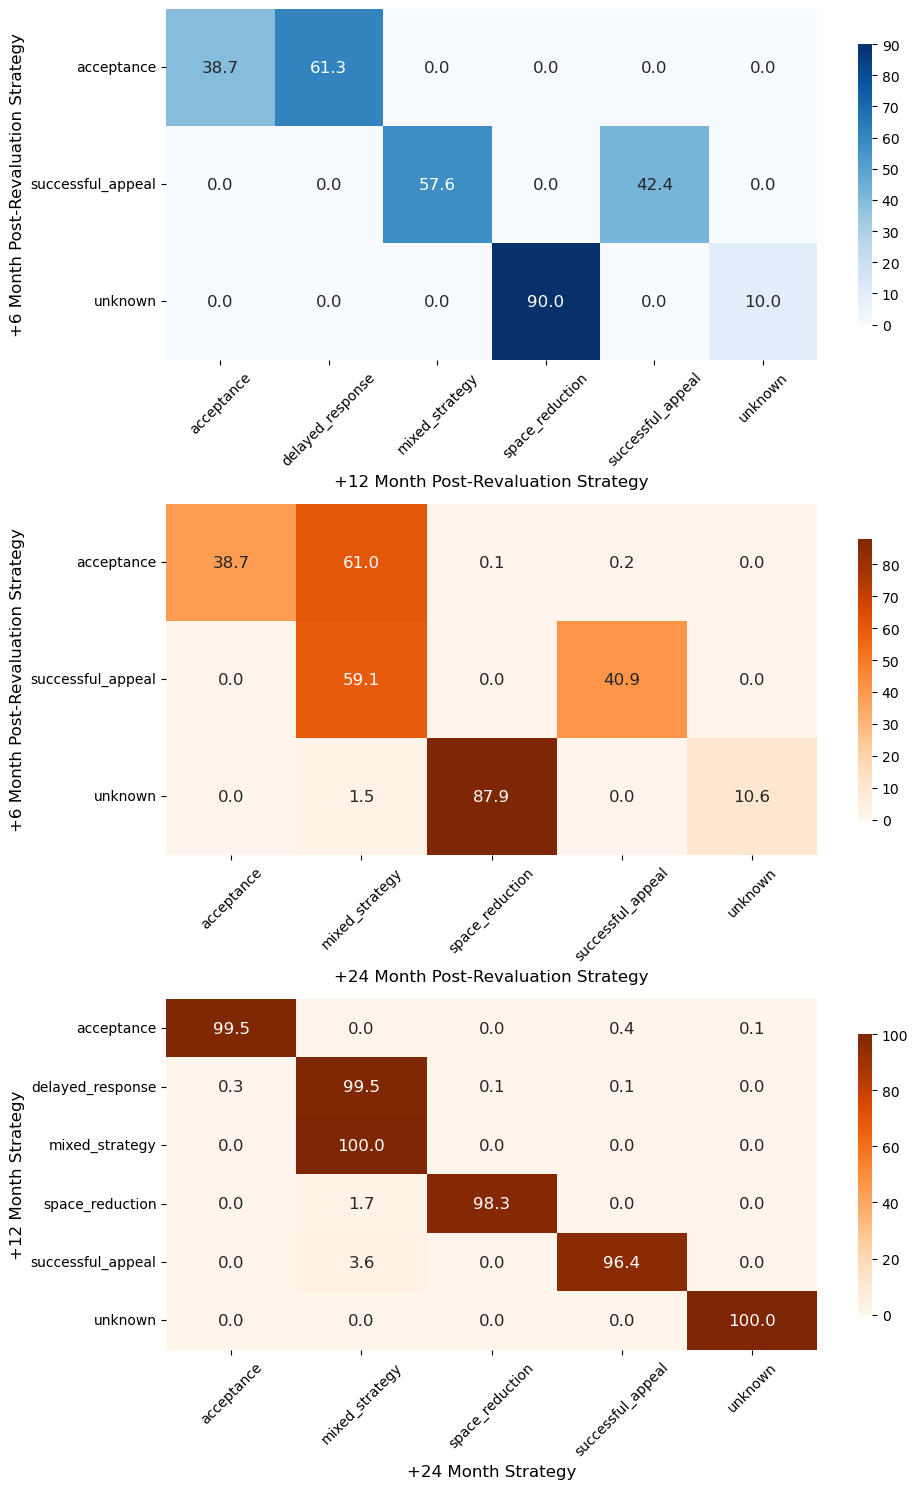


Transition matrix numerical summary:
=== TRANSITION MATRIX SUMMARY ===

1. +6 → +12 months transition:
+12                acceptance  delayed_response  mixed_strategy  \
+6                                                                
acceptance               38.7              61.3             0.0   
successful_appeal         0.0               0.0            57.6   
unknown                   0.0               0.0             0.0   

+12                space_reduction  successful_appeal  unknown  
+6                                                              
acceptance                     0.0                0.0      0.0  
successful_appeal              0.0               42.4      0.0  
unknown                       90.0                0.0     10.0  
   - Most stable strategy: unknown (90.0% retention)
   - Highest transition: 90.0%

2. +6 → +24 months transition:
+24                acceptance  mixed_strategy  space_reduction  \
+6                                                   

In [121]:
def visualize_three_transition_matrices(results):
    """
    Visualize only the three transition matrices
    """
 
    has_24_months = 'three_period_analyzed' in results and results['three_period_analyzed'] > 0
    if not has_24_months:
        print("Warning: No 24-month data, showing only +6 → +12 transition matrix")
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        
        # Show only +6 → +12 transition matrix
        transition_pct_12 = results['transition_percentages_12']
        sns.heatmap(transition_pct_12, annot=True, fmt='.1f', cmap='Oranges', 
                   ax=ax, cbar_kws={'shrink': 0.8})
        ax.set_title('Strategy Transition Matrix (+6 → +12 months)', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Strategy at +12 Months', fontsize=12)
        ax.set_ylabel('Strategy at +6 Months', fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)
        
        plt.tight_layout()
        plt.show()
        return
    

    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    
    
    # 1. +6 → +12 transition matrix
    transition_pct_12 = results['transition_percentages_12']
    sns.heatmap(transition_pct_12, annot=True, fmt='.1f', annot_kws={'size': 12}, cmap='Blues', 
               ax=axes[0], cbar_kws={'shrink': 0.8})
    #axes[0].set_title('Transition Matrix\n(+6 → +12 months)', 
     #                fontsize=14, fontweight='bold')
    axes[0].set_xlabel('+12 Month Post-Revaluation Strategy', fontsize=12)
    axes[0].set_ylabel('+6 Month Post-Revaluation Strategy', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # 2. +6 → +24 transition matrix
    if 'transition_percentages_24' in results and not results['transition_percentages_24'].empty:
        transition_pct_24 = results['transition_percentages_24']
        sns.heatmap(transition_pct_24, annot=True, fmt='.1f', annot_kws={'size': 12}, cmap='Oranges', 
                   ax=axes[1], cbar_kws={'shrink': 0.8})
        #axes[1].set_title('Transition Matrix\n(+6 → +24 months)', 
        #                 fontsize=14, fontweight='bold')
        axes[1].set_xlabel('+24 Month Post-Revaluation Strategy', fontsize=12)
        axes[1].set_ylabel('+6 Month Post-Revaluation Strategy', fontsize=12)
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].tick_params(axis='y', rotation=0)
    else:
        axes[1].text(0.5, 0.5, 'No +6 → +24\nTransition Data', 
                    ha='center', va='center', transform=axes[1].transAxes, 
                    fontsize=14, fontweight='bold')
        #axes[1].set_title('Transition Matrix\n(+6 → +24 months)', 
        #                 fontsize=14, fontweight='bold')
    
    # 3. +12 → +24 transition matrix
    if 'transition_percentages_12_24' in results and not results['transition_percentages_12_24'].empty:
        transition_pct_12_24 = results['transition_percentages_12_24']
        sns.heatmap(transition_pct_12_24, annot=True, fmt='.1f', annot_kws={'size': 12}, cmap='Oranges', 
                   ax=axes[2], cbar_kws={'shrink': 0.8})
        #axes[2].set_title('Transition Matrix\n(+12 → +24 months)', 
        #                 fontsize=14, fontweight='bold')
        axes[2].set_xlabel('+24 Month Strategy', fontsize=12)
        axes[2].set_ylabel('+12 Month Strategy', fontsize=12)
        axes[2].tick_params(axis='x', rotation=45)
        axes[2].tick_params(axis='y', rotation=0)
    else:
        axes[2].text(0.5, 0.5, 'No +12 → +24\nTransition Data', 
                    ha='center', va='center', transform=axes[2].transAxes, 
                    fontsize=12, fontweight='bold')
        #axes[2].set_title('Transition Matrix\n(+12 → +24 months)', 
        #                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    #plt.savefig('transition_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_transition_summary(results):
    """
    Print numerical summaries of the transition matrices
    """
    print("=== TRANSITION MATRIX SUMMARY ===\n")
    
    # +6 → +12 summary
    print("1. +6 → +12 months transition:")
    if 'transition_percentages_12' in results:
        trans_12 = results['transition_percentages_12']
        print(trans_12.round(1))
        print(f"   - Most stable strategy: {trans_12.max(axis=1).idxmax()} ({trans_12.max(axis=1).max():.1f}% retention)")
        print(f"   - Highest transition: {trans_12.fillna(0).values.max():.1f}%")
    
    # +6 → +24 summary
    if 'transition_percentages_24' in results and not results['transition_percentages_24'].empty:
        print("\n2. +6 → +24 months transition:")
        trans_24 = results['transition_percentages_24']
        print(trans_24.round(1))
        print(f"   - Most stable strategy: {trans_24.max(axis=1).idxmax()} ({trans_24.max(axis=1).max():.1f}% retention)")
        print(f"   - Highest transition: {trans_24.fillna(0).values.max():.1f}%")
    
    # +12 → +24 summary
    if 'transition_percentages_12_24' in results and not results['transition_percentages_12_24'].empty:
        print("\n3. +12 → +24 months transition:")
        trans_12_24 = results['transition_percentages_12_24']
        print(trans_12_24.round(1))
        print(f"   - Most stable strategy: {trans_12_24.max(axis=1).idxmax()} ({trans_12_24.max(axis=1).max():.1f}% retention)")
        print(f"   - Highest transition: {trans_12_24.fillna(0).values.max():.1f}%")


def show_transition_matrices(response_df):
    """
    Full transition matrix analysis and visualization
    """
    print("Analyzing strategy transition matrices...")
    
    # Run analysis
    results = analyze_strategy_consistency_and_delay(response_df)
    
    print("\nDisplaying transition matrix visualizations...")
    visualize_three_transition_matrices(results)
    
    print("\nTransition matrix numerical summary:")
    print_transition_summary(results)
    
    return results


matrix_results = show_transition_matrices(strategy_2017N)

## Survival analysis

### Calculate firm-level survival rate

In [122]:
def track_business_survival(df):
   """Track business survival across different time points"""
   
   # Baseline: Use 12 months before revaluation
   baseline = df[df['timepoint'] == "-12"].dropna(subset=['rateable_value'])
   
   survival_data = []
   
   for borough in baseline['borough'].unique():
       borough_baseline = baseline[baseline['borough'] == borough]
       baseline_uarns = set(borough_baseline['uarn'])
       
       for period in df['timepoint'].unique():
           if period == "-12":
               continue
               
           df_clean = df[(df['timepoint'] == period) & (df['borough'] == borough)].dropna(subset=['rateable_value'])
           current_uarns = set(df_clean['uarn'])
           
           # Calculate survival rate
           survived = len(baseline_uarns & current_uarns)
           survival_rate = survived / len(baseline_uarns) * 100 if len(baseline_uarns) > 0 else 0
           
           # Analyze by threshold groups
           for threshold in [15000]:
               near_threshold = borough_baseline[
                   (borough_baseline['rateable_value'] >= threshold-500) & 
                   (borough_baseline['rateable_value'] <= threshold+500)
               ]
               near_threshold_uarns = set(near_threshold['uarn'])
               
               survived_near = len(near_threshold_uarns & current_uarns)
               survival_rate_near = survived_near / len(near_threshold_uarns) * 100 if len(near_threshold_uarns) > 0 else 0
               
               survival_data.append({
                   'period': period,
                   'borough': borough,
                   'threshold': threshold,
                   'total_baseline': len(baseline_uarns),
                   'near_threshold_baseline': len(near_threshold_uarns),
                   'survived_total': survived,
                   'survived_near_threshold': survived_near,
                   'survival_rate_total': survival_rate,
                   'survival_rate_near_threshold': survival_rate_near
               })
   
   return pd.DataFrame(survival_data)

In [123]:
survival_2017=track_business_survival(data_2017)
survival_2023=track_business_survival(data_2023)

survival_2017.head()

,period,borough,threshold,total_baseline,near_threshold_baseline,survived_total,survived_near_threshold,survival_rate_total,survival_rate_near_threshold
0,-6,City of London,15000,19463,326,19448,326,99.922931,100.000000
1,0,City of London,15000,19463,326,18165,297,93.330936,91.104294
2,+6,City of London,15000,19463,326,18719,307,96.177362,94.171779
3,+12,City of London,15000,19463,326,18907,315,97.143298,96.625767
4,+24,City of London,15000,19463,326,18549,314,95.303910,96.319018


In [78]:
survival_2017['borough'].unique()

array(['City of London', 'Camden', 'Hackney', 'Westminster'], dtype=object)

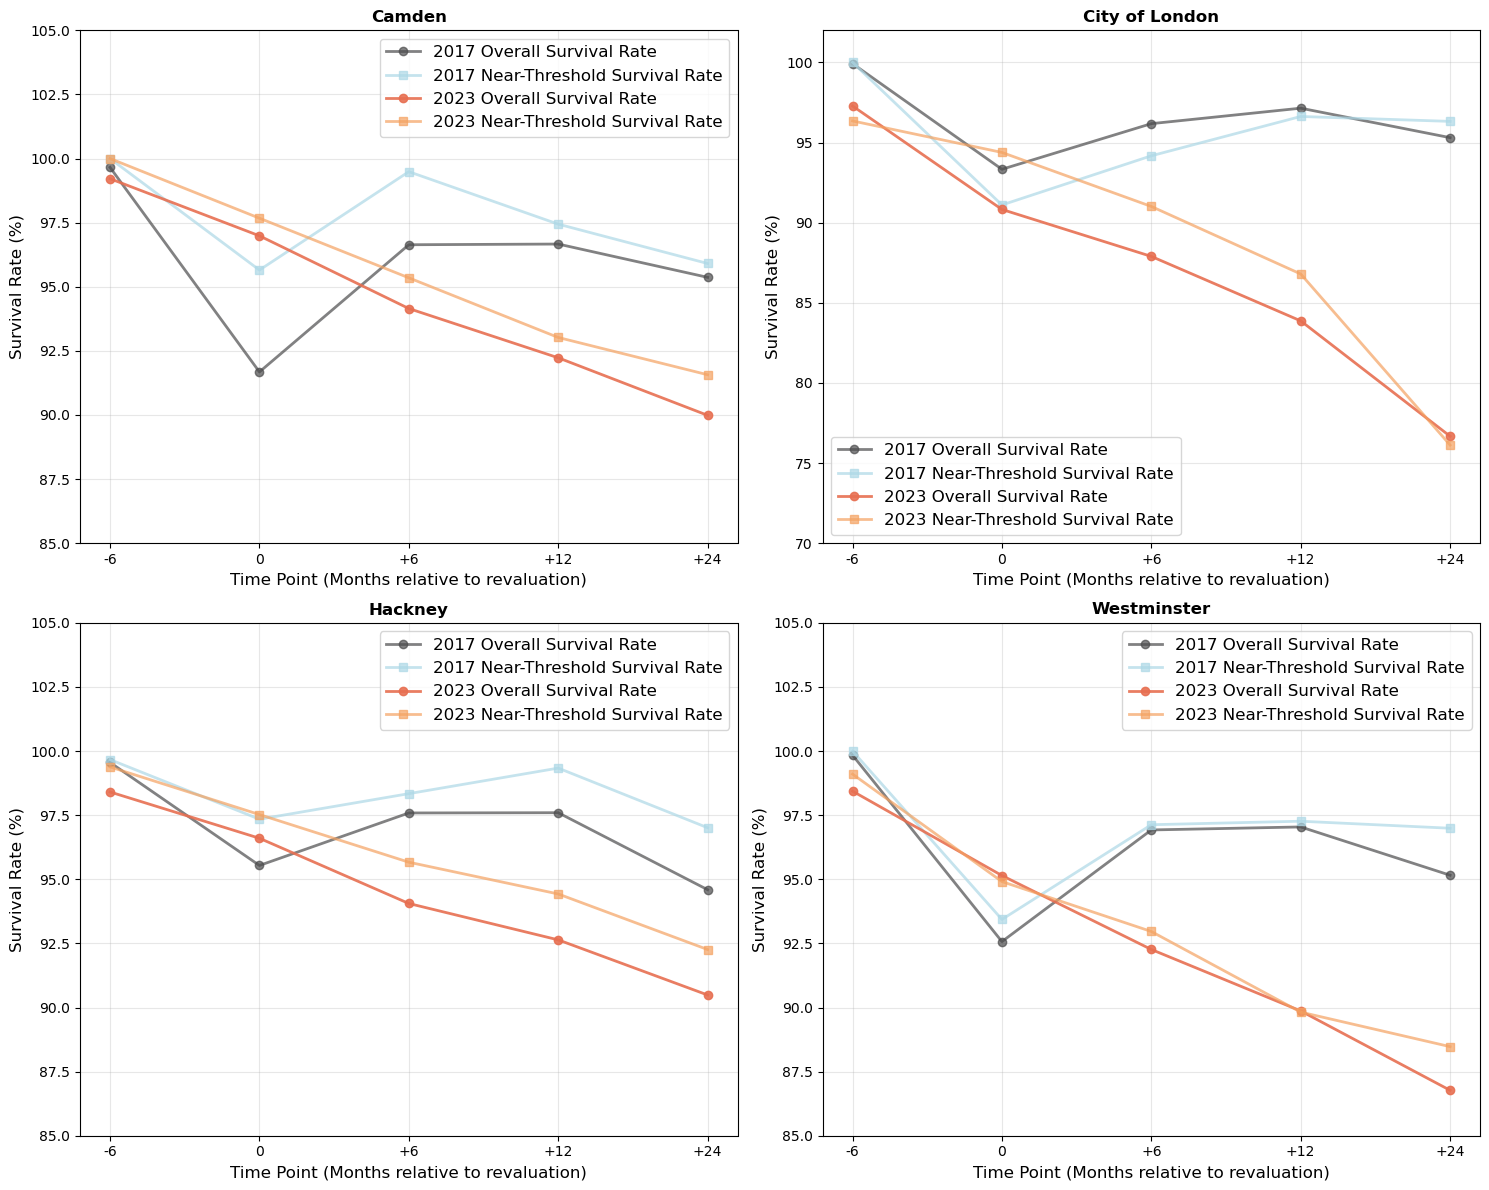

In [124]:
def plot_survival_comparison(survival_2017, survival_2023):
   """Plot survival rate comparison for four boroughs"""
   
   # Define time order
   time_order = ['-6', '0', '+6', '+12', '+24']
   
   # Get four boroughs
   boroughs = sorted(survival_2017['borough'].unique())
   
   # Create 2x2 subplots
   fig, axes = plt.subplots(2, 2, figsize=(15, 12))
   axes = axes.flatten()
   
   for i, borough in enumerate(boroughs):
       ax = axes[i]
       
       # Extract 2017 data
       data_2017 = survival_2017[survival_2017['borough'] == borough]
       data_2017 = data_2017[data_2017['period'].isin(time_order)]
       data_2017['period'] = pd.Categorical(data_2017['period'], categories=time_order, ordered=True)
       data_2017 = data_2017.sort_values('period')
       
       # Extract 2023 data
       data_2023 = survival_2023[survival_2023['borough'] == borough]
       data_2023 = data_2023[data_2023['period'].isin(time_order)]
       data_2023['period'] = pd.Categorical(data_2023['period'], categories=time_order, ordered=True)
       data_2023 = data_2023.sort_values('period')
       
       # Plot 2017 lines
       ax.plot(data_2017['period'], data_2017['survival_rate_total'], 'o-', linewidth=2, 
               label='2017 Overall Survival Rate', color='#4c4c4d', alpha=0.7, markersize=6)
       ax.plot(data_2017['period'], data_2017['survival_rate_near_threshold'], 's-', linewidth=2, 
               label='2017 Near-Threshold Survival Rate', color='lightblue', alpha=0.7, markersize=6)
       
       # Plot 2023 lines
       ax.plot(data_2023['period'], data_2023['survival_rate_total'], 'o-', linewidth=2, 
               label='2023 Overall Survival Rate', color='#e76f51', alpha=0.9, markersize=6)
       ax.plot(data_2023['period'], data_2023['survival_rate_near_threshold'], 's-', linewidth=2, 
               label='2023 Near-Threshold Survival Rate', color='#f4a261', alpha=0.7, markersize=6)
       
       # Set chart propertie
       ax.set_title(f'{borough}', 
                   fontsize=12, fontweight='bold')
       ax.set_xlabel('Time Point (Months relative to revaluation)',fontsize=12)
       ax.set_ylabel('Survival Rate (%)',fontsize=12)
       ax.legend(fontsize=12)
       ax.grid(True, alpha=0.3)
       
       if borough == 'City of London':
           ax.set_ylim(70, 102)  
       else:
           ax.set_ylim(85, 105)  

       
       # Set x-axis labels
       ax.set_xticks(range(len(time_order)))
       ax.set_xticklabels(time_order)
   
   plt.tight_layout()
   #plt.suptitle('Business Survival Rate Comparison Across Four Boroughs: 2017 vs 2023 Revaluation Cycles', 
   #             fontsize=16, fontweight='bold', y=1.02)
   plt.savefig('survival_rate_comparison.png', dpi=300, bbox_inches='tight') 
   plt.show()


# Call functions
plot_survival_comparison(survival_2017, survival_2023)
#plot_overall_comparison(survival_2017, survival_2023)

### Calculate borough-level survival rate

In [127]:
#!pip install lifelines
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

In [128]:
def prepare_survival_data(df, baseline_period="-12", revaluation_year=2017):
    df = df.copy()
    df["timepoint"] = df["timepoint"].astype(str)

    # Define time mapping (starting from revaluation timepoint 0)
    timepoint_mapping = {
        "0": 0,
        "+6": 6,
        "+12": 12,
        "+24": 24
    }

    # —— 1. Filter baseline cohort —— #
    baseline = df[(df["timepoint"] == baseline_period) & df["rateable_value"].notna()].copy()
    baseline_uarns = baseline["uarn"].unique()
    print(f"Total baseline businesses: {len(baseline_uarns)}")

    # —— 2. Prepare observation period data (excluding -12) —— #
    df_obs = df[df["timepoint"].isin(timepoint_mapping.keys())].dropna(subset=["rateable_value"]).copy()
    df_obs["time_months"] = df_obs["timepoint"].map(timepoint_mapping)

    available_periods = sorted(df_obs["timepoint"].unique(), key=lambda t: timepoint_mapping[t])
    max_time_available = max(timepoint_mapping[t] for t in available_periods)
    print(f"Available observation periods: {available_periods}")

    # —— Construct presence matrix (rows=uarn, columns=timepoints), True=observed in that period —— #
    # Only need columns after baseline for "first missing" determination
    periods_after = [p for p in available_periods if p != baseline_period]

    # Wide format: whether observed (existence of any rateable_value record = True)
    pres = (
        df_obs
        .assign(present=True)
        .pivot_table(index='uarn', columns='timepoint', values='present', aggfunc='max', fill_value=False)
        .reindex(columns=periods_after, fill_value=False)  # Keep only post-baseline columns, ensure column order
    )

    # Mark "first missing" index for each uarn (position relative to periods_after)
    # If no missing exists (all True), first_missing_idx is recorded as -1
    pres_values = pres.values
    # Missing means False
    missing_values = ~pres_values
    # Find first True (missing position) for each row
    has_missing = missing_values.any(axis=1)
    first_missing_idx = np.argmax(missing_values, axis=1)
    # Correct rows with "no missing" to -1
    first_missing_idx = np.where(has_missing, first_missing_idx, -1)

    # Calculate "last actual observation time" for each uarn (maximum time_months from df_obs)
    last_obs_time = (
        df_obs.groupby('uarn')['time_months']
        .max()
        .reindex(pres.index)  # Align with presence uarn
    )

    # For calculating exit midpoint: need "time point (months) corresponding to first missing"
    # For first_missing_idx = k >= 0, corresponding next_time = timepoint_mapping[periods_after[k]]
    next_time_arr = np.full(len(pres), np.nan, dtype=float)
    valid_rows = first_missing_idx >= 0
    if len(periods_after) > 0:
        next_time_arr[valid_rows] = np.array(
            [timepoint_mapping[periods_after[i]] for i in first_missing_idx[valid_rows]]
        )

    # Calculate exit time: exit_time = last_observed + (next_time - last_observed)/2
    # If no missing (first_missing_idx == -1), exit_time is NaN (right-censored)
    last_obs_arr = last_obs_time.values.astype(float)
    exit_time = np.where(
        valid_rows,
        last_obs_arr + (next_time_arr - last_obs_arr) / 2.0,
        np.nan
    )

    # Event indicator: missing = 1, otherwise 0
    event_occurred = (first_missing_idx >= 0).astype(int)

    # Survival time:
    # - If event occurred: survival_time = exit_time
    # - If not occurred: survival_time = max_time_available (or could use last_obs_time, depends on censoring definition. Use max_time to align with original implementation)
    survival_time = np.where(
        event_occurred == 1,
        exit_time,
        max_time_available
    )

    # —— Other business attributes: merge from baseline —— #
    # Quartiles: possible duplicate quantile points, use duplicates='drop'
    quartile_labels = pd.qcut(
        baseline['rateable_value'],
        q=4,
        labels=['Q1_Small', 'Q2_Small-Medium', 'Q3_Medium-Large', 'Q4_Large'],
        duplicates='drop'
    )
    uarn_to_quartile = dict(zip(baseline['uarn'], quartile_labels.astype(str)))

    base_cols = ['uarn', 'borough', 'category_group', 'rateable_value', 'total_floor_area']
    for col in base_cols:
        if col not in baseline.columns:
            # Fill missing columns with NaN to avoid KeyError
            baseline[col] = np.nan

    base_info = baseline[['uarn', 'borough', 'category_group', 'rateable_value', 'total_floor_area']].drop_duplicates()
    base_info = base_info.set_index('uarn').reindex(pres.index)

    rv = base_info['rateable_value'].astype(float)
    near_threshold = (rv.between(14500, 15500, inclusive='both')).values
    threshold_distance = (rv - 15000).abs().values

    # Summary results table
    survival_df = pd.DataFrame({
        'uarn': pres.index,
        'borough': base_info['borough'].values,
        'category_group': base_info['category_group'].values,
        'baseline_rateable_value': rv.values,
        'total_floor_area': base_info['total_floor_area'].values,
        'revaluation_year': revaluation_year,
        'near_threshold': near_threshold.astype(bool),
        'threshold_distance': threshold_distance.astype(float),
        'size_quartile': [uarn_to_quartile.get(u, np.nan) for u in pres.index],
        'survival_time': survival_time.astype(float),
        'event_occurred': event_occurred.astype(int),
        'exit_time': exit_time.astype(float),
        'last_observed': last_obs_arr.astype(float),
    })

    # Only keep uarns that actually appeared in baseline (consistent with original logic)
    survival_df = survival_df[survival_df['uarn'].isin(baseline_uarns)].reset_index(drop=True)

    # Summary
    print(f"\nSurvival analysis data summary:")
    print(f"Total businesses: {len(survival_df)}")
    print(f"Exit events occurred: {survival_df['event_occurred'].sum()}")
    print(f"Right-censored: {len(survival_df) - survival_df['event_occurred'].sum()}")
    print(f"Near-threshold businesses: {survival_df['near_threshold'].sum()}")

    return survival_df

In [129]:
survival_data_2017 = prepare_survival_data(data_2017, baseline_period="-12", revaluation_year=2017)
survival_data_2023 = prepare_survival_data(data_2023, baseline_period="-12", revaluation_year=2023)

# View generated data structure
print("2017 survival data first 5 rows:")
print(survival_data_2017.head())
print("\n2023 survival data first 5 rows:")
print(survival_data_2023.head())

Total baseline businesses: 84002
Available observation periods: ['0', '+6', '+12', '+24']

Survival analysis data summary:
Total businesses: 83708
Exit events occurred: 9246
Right-censored: 74462
Near-threshold businesses: 1744
Total baseline businesses: 88875
Available observation periods: ['0', '+6', '+12', '+24']

Survival analysis data summary:
Total businesses: 84162
Exit events occurred: 8126
Right-censored: 76036
Near-threshold businesses: 1621
2017 survival data first 5 rows:
      uarn  borough category_group  baseline_rateable_value  total_floor_area  \
0   387068  Hackney     industrial                   9200.0            148.23   
1   903068  Hackney          other                  29250.0               NaN   
2  1072063   Camden        leisure                 117000.0               NaN   
3  1072068  Hackney         retail                   9000.0             77.10   
4  1073068  Hackney         retail                   9800.0             92.30   

   revaluation_year  nea

In [ ]:
def track_business_survival_borough(df):
    """Track business survival across different time points for individual businesses"""
    
    # Baseline: Use 12 months before revaluation as reference point
    baseline = df[df['timepoint'] == "-12"].dropna(subset=['rateable_value'])
    baseline_uarns = set(baseline['uarn'])
    
    survival_data = []
    
    for period in df['timepoint'].unique():
        if period == "-12":
            continue
            
        # Get businesses that exist in current period
        df_clean = df[df['timepoint'] == period].dropna(subset=['rateable_value'])
        current_uarns = set(df_clean['uarn'])
        
        # Loop through each business in baseline
        for _, business in baseline.iterrows():
            uarn = business['uarn']
            
            # Check if this business survived to current period
            survived = 1 if uarn in current_uarns else 0
            
            # Determine if business is near threshold (15000 ± 500)
            is_near_threshold = 1 if (business['rateable_value'] >= 14500 and 
                                    business['rateable_value'] <= 15500) else 0
            
            survival_data.append({
                'period': period,
                'uarn': uarn,
                'borough': business['borough'],
                'category_group': business['category_group'] if 'category_group' in business else None,
                'baseline_rateable_value': business['rateable_value'],
                'is_near_threshold': is_near_threshold,
                'survived': survived
            })
    
    return pd.DataFrame(survival_data)

def calculate_survival_rates(survival_df):
    """Calculate survival rates from individual business survival data"""
    
    # Define time order
    time_order = ['0', '+6', '+12', '+24']
    available_periods = [p for p in time_order if p in survival_df['period'].unique()]
    
    # Filter and sort by time order
    survival_df_filtered = survival_df[survival_df['period'].isin(available_periods)].copy()
    survival_df_filtered['period'] = pd.Categorical(survival_df_filtered['period'], 
                                                   categories=available_periods, ordered=True)
    
    # Overall survival rate by period
    overall_rates = survival_df_filtered.groupby('period').agg({
        'survived': ['count', 'sum']
    }).round(2)
    overall_rates.columns = ['total_businesses', 'survived_businesses']
    overall_rates['survival_rate'] = (overall_rates['survived_businesses'] / 
                                    overall_rates['total_businesses'] * 100).round(2)
    
    # Near-threshold survival rate by period
    threshold_data = survival_df_filtered[survival_df_filtered['is_near_threshold'] == 1]
    if len(threshold_data) > 0:
        threshold_rates = threshold_data.groupby('period').agg({
            'survived': ['count', 'sum']
        }).round(2)
        threshold_rates.columns = ['total_near_threshold', 'survived_near_threshold']
        threshold_rates['threshold_survival_rate'] = (threshold_rates['survived_near_threshold'] / 
                                                     threshold_rates['total_near_threshold'] * 100).round(2)
    else:
        threshold_rates = pd.DataFrame()
    
    # By borough
    borough_rates = survival_df_filtered.groupby(['period', 'borough']).agg({
        'survived': ['count', 'sum']
    }).round(2)
    borough_rates.columns = ['total', 'survived']
    borough_rates['survival_rate'] = (borough_rates['survived'] / borough_rates['total'] * 100).round(2)
    
    return overall_rates, threshold_rates, borough_rates


def print_survival_summary(survival_df):
    """Print survival rate summary"""
    
    overall, threshold, by_borough = calculate_survival_rates(survival_df)
    
    print("=== SURVIVAL ANALYSIS SUMMARY ===")
    print("\n1. Overall Survival Rates:")
    print(overall[['total_businesses', 'survived_businesses', 'survival_rate']])
    
    if not threshold.empty:
        print("\n2. Near-Threshold Survival Rates:")
        print(threshold[['total_near_threshold', 'survived_near_threshold', 'threshold_survival_rate']])
    
    print("\n3. Survival Rates by Borough:")
    borough_summary = by_borough.reset_index().groupby('borough')['survival_rate'].agg(['mean', 'min', 'max']).round(2)
    print(borough_summary)

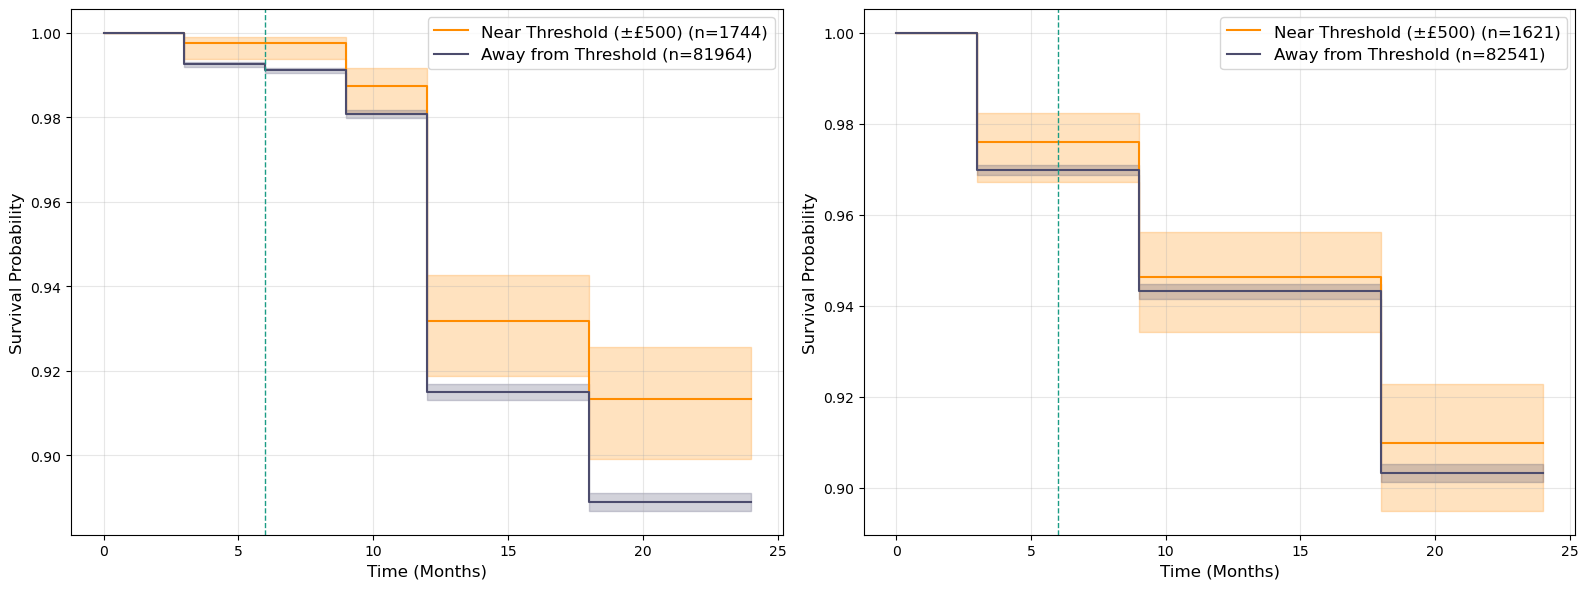

In [130]:
def plot_km_threshold_two(s2017, s2023):
    """
    Creates side-by-side Kaplan-Meier survival curves comparing 
    near-threshold vs away-from-threshold firms for 2017 (left panel) and 2023 (right panel).
    """
    fig, axes = plt.subplots(1, 2, figsize=(16,6)) 
    
    for ax, data, year in zip(axes, [s2017, s2023], [2017, 2023]):
        kmf = KaplanMeierFitter()
        for val, color in zip([True, False], ["darkorange", "#4c4c6d"]):
            sub = data[data['near_threshold'] == val]
            if len(sub) == 0:
                continue
            label = "Near Threshold (±£500)" if val else "Away from Threshold"
            label = f"{label} (n={len(sub)})"
            kmf.fit(sub['survival_time'], sub['event_occurred'], label=label)
            kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

        ax.axvline(6, color="#1b9c85", linestyle="--", linewidth=1)
        #ax.set_title(f"Kaplan–Meier: £15k Threshold Groups ({year})")
        ax.set_xlabel("Time (Months)",fontsize=12)
        ax.set_ylabel("Survival Probability",fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12)
    
    plt.tight_layout()
    #plt.savefig("km_threshold_2017_vs_2023.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_km_threshold_two(survival_data_2017, survival_data_2023)


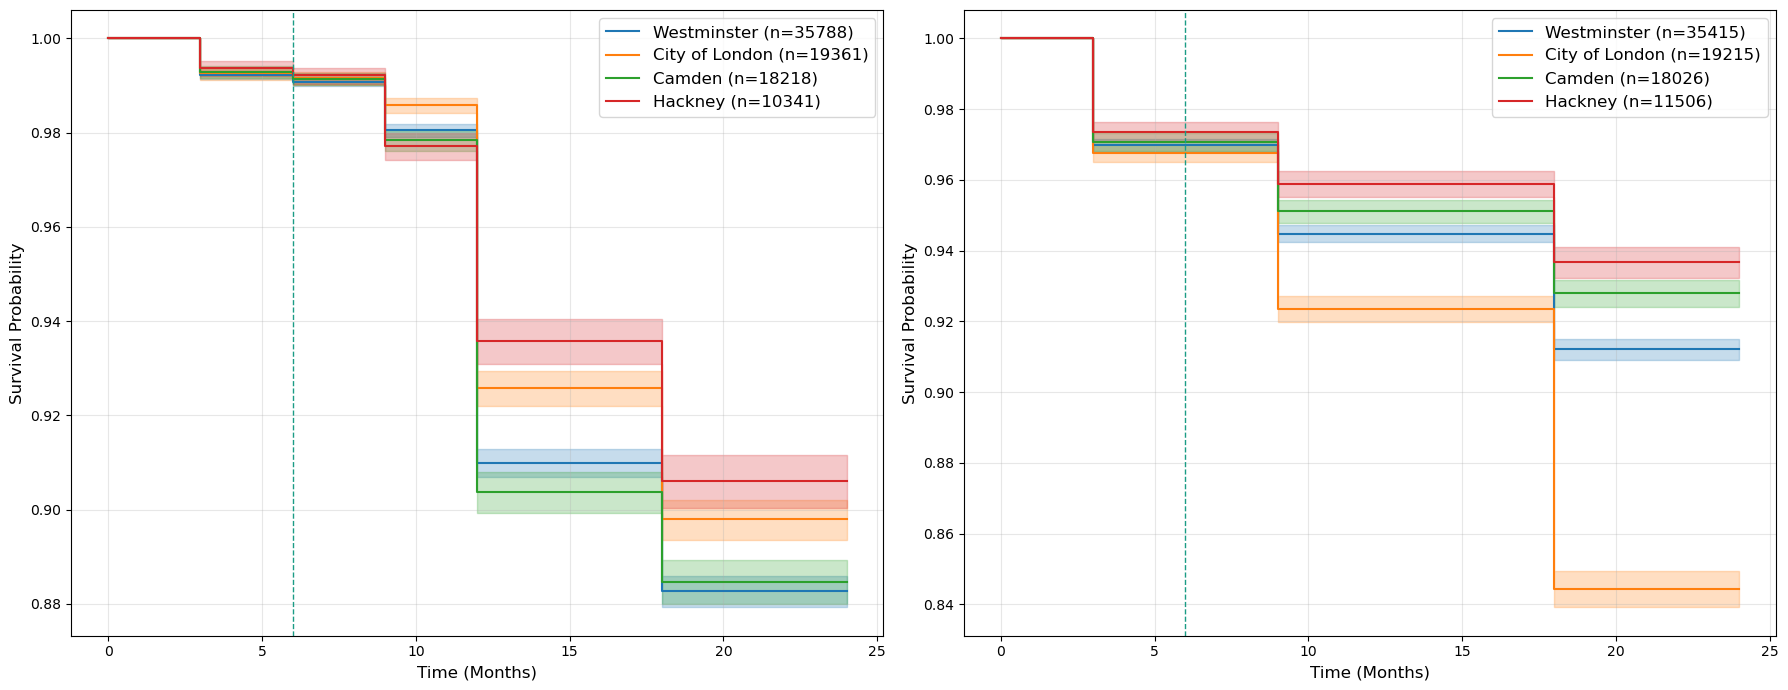

In [131]:
def plot_km_by_two(s2017, s2023, group_by,
                   max_groups=8, min_group_size=30,
                   title_prefix='Kaplan–Meier by ',
                   save_path=None):
    """
    Side-by-side plots: left=2017, right=2023
   - Each subplot shows survival curves grouped by group_by variable
   - Automatically filters groups with sample size >= min_group_size
   - Takes top max_groups by sample size in descending order
    """
    fig, axes = plt.subplots(1, 2, figsize=(18,7))

    for ax, data, year in zip(axes, [s2017, s2023], [2017, 2023]):
        counts = data[group_by].value_counts().rename('n')
        valid_groups = counts[counts >= min_group_size].head(max_groups).index.tolist()
        if len(valid_groups) == 0:
            ax.set_title(f"{year}: no valid groups for {group_by}")
            continue

        for g in valid_groups:
            sub = data[data[group_by] == g]
            kmf = KaplanMeierFitter()
            kmf.fit(
                durations=sub['survival_time'],
                event_observed=sub['event_occurred'],
                label=f'{g} (n={len(sub)})'
            )
            kmf.plot_survival_function(ax=ax, ci_show=True)

        ax.axvline(6, color="#1b9c85", linestyle="--", linewidth=1)
        #.set_title(f"{title_prefix}{group_by.replace('_',' ').title()} ({year})")
        ax.set_xlabel('Time (Months)',fontsize=12)
        ax.set_ylabel('Survival Probability',fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12)

   
    plt.tight_layout()
    #plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    
# Compare by borough
plot_km_by_two(survival_data_2017, survival_data_2023, group_by='borough',
               max_groups=6, min_group_size=1000,
               title_prefix='Kaplan–Meier by Borough',
               save_path="km_by_borough.png")


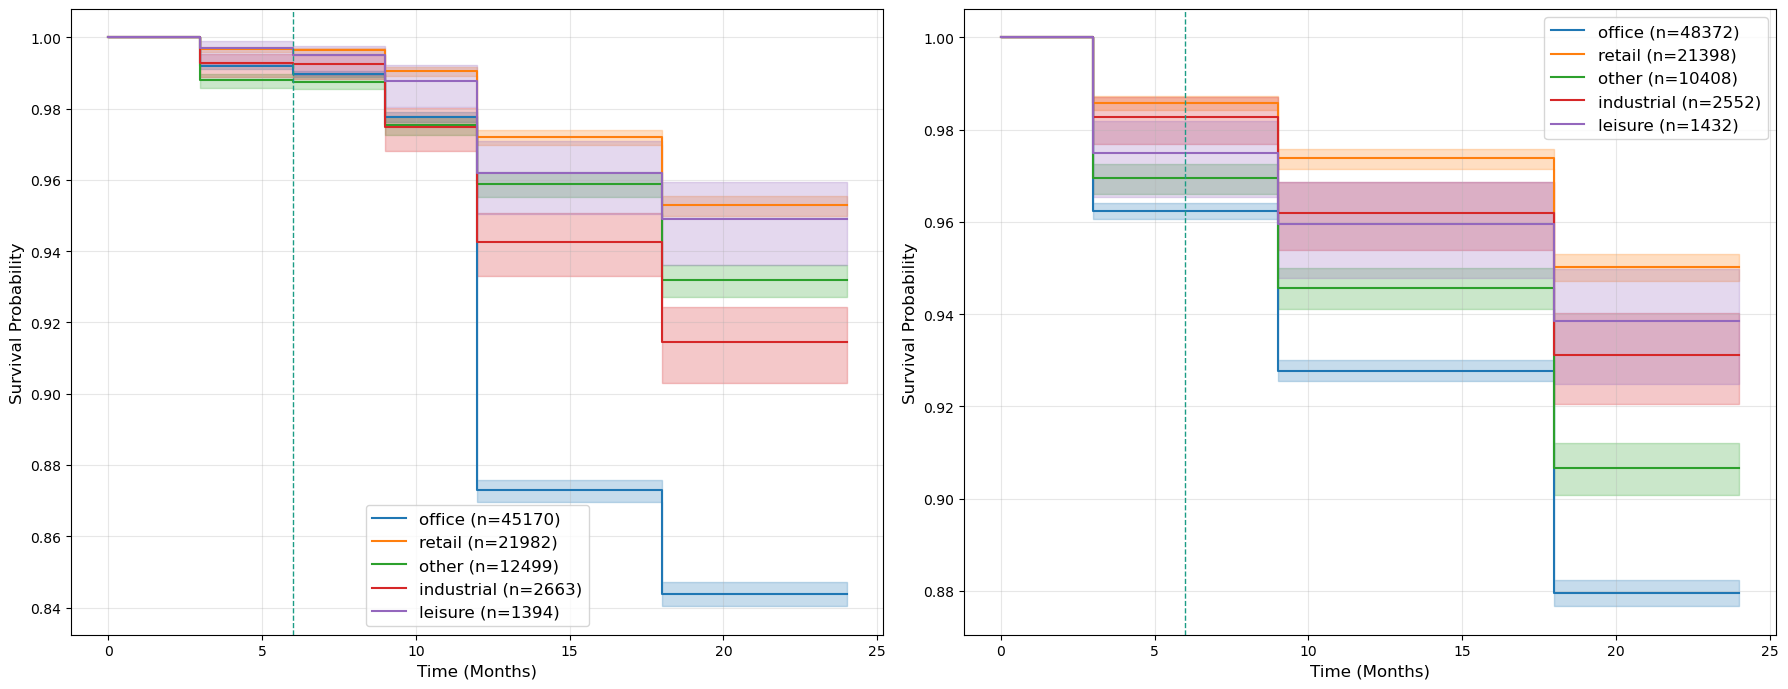

In [132]:
# Compare by category
plot_km_by_two(survival_data_2017, survival_data_2023, group_by='category_group',
               max_groups=8, min_group_size=50,
               title_prefix='Kaplan–Meier by Category',
               save_path="km_by_category.png")

In [133]:
def print_km_summary(data, group_by):
    print(f"\n=== {group_by} summary (n={len(data)}) ===")
    for g, sub in data.groupby(group_by):
        n_total = len(sub)
        n_events = sub['event_occurred'].sum()
        n_censored = n_total - n_events
        print(f"{g}: n={n_total}, events={n_events}, censored={n_censored}")


print_km_summary(survival_data_2017, "borough")
print_km_summary(survival_data_2023, "borough")


=== borough summary (n=83708) ===
Camden: n=18218, events=2100, censored=16118
City of London: n=19361, events=1976, censored=17385
Hackney: n=10341, events=971, censored=9370
Westminster: n=35788, events=4199, censored=31589

=== borough summary (n=84162) ===
Camden: n=18026, events=1297, censored=16729
City of London: n=19215, events=2991, censored=16224
Hackney: n=11506, events=728, censored=10778
Westminster: n=35415, events=3110, censored=32305


## Robustness Checks

In [138]:
def analyze_bunching_by_borough_timepoint_flexible(data_2017, thresholds=[15000], window=1000):
    """
    Analyze bunching effect by borough and timepoint with flexible window size
    
    Parameters:
    data_2017: DataFrame with columns including 'borough', 'timepoint', 'rateable_value'
    thresholds: list of threshold values to analyze
    window: window size around threshold (default 1000, can be modified to 1500)
    
    Returns:
    DataFrame with bunching distortion by borough and timepoint
    """
    
    # Create timepoint mapping for proper ordering
    timepoint_mapping = {
        '-12': 'pre_12m',
        '-6': 'pre_6m', 
        '0': 'revaluation',
        '+6': 'post_6m',
        '+12': 'post_12m',
        '+24': 'post_24m',
        'other': 'other'
    }
    
    results = []
    
    # Get unique boroughs and timepoints
    boroughs = data_2017['borough'].unique()
    timepoints = sorted(data_2017['timepoint'].unique())
    
    for borough in boroughs:
        for timepoint in timepoints:
            # Filter data for this borough and timepoint
            subset = data_2017[(data_2017['borough'] == borough) & 
                              (data_2017['timepoint'] == timepoint)]
            
            if len(subset) == 0:
                continue
                
            # Clean data
            subset_clean = subset[subset['rateable_value'].notna()]
            
            if len(subset_clean) == 0:
                continue
            
            for threshold in thresholds:
                # Count observations before and after threshold
                before = len(subset_clean[
                    (subset_clean['rateable_value'] >= threshold - window) & 
                    (subset_clean['rateable_value'] < threshold)
                ])
                
                after = len(subset_clean[
                    (subset_clean['rateable_value'] >= threshold) & 
                    (subset_clean['rateable_value'] <= threshold + window)
                ])
                
                # Calculate bunching distortion
                ratio = before / max(after, 1)
                distortion = (ratio - 1) * 100
                
                # Map timepoint to period name
                period_name = timepoint_mapping.get(timepoint, f'timepoint_{timepoint}')
                
                results.append({
                    'Borough': borough,
                    'timepoint': timepoint,
                    'period': period_name,
                    'threshold': threshold,
                    'window_size': window,
                    'before_count': before,
                    'after_count': after,
                    'ratio': ratio,
                    'distortion_pct': distortion
                })
    
    return pd.DataFrame(results)

# Usage examples for different window sizes:

# With window=1000
bunching_results_1000 = analyze_bunching_by_borough_timepoint_flexible(
    data_2017, 
    thresholds=[15000], 
    window=1000
)

# With window=1500  
bunching_results_1500 = analyze_bunching_by_borough_timepoint_flexible(
    data_2017, 
    thresholds=[15000], 
    window=1500
)

def compare_window_effects(data, window_sizes=[1000, 1500]):
    """
    Compare bunching effects across different window sizes
    """
    results = {}
    
    for window in window_sizes:
        results[f'window_{window}'] = analyze_bunching_by_borough_timepoint_flexible(
            data, 
            thresholds=[15000], 
            window=window
        )
    
    return results

def plot_bunching_comparison(data, window_sizes=[1000, 1500]):
    """
    Create comparison plots for different window sizes
    """
    fig, axes = plt.subplots(1, len(window_sizes), figsize=(15, 6))
    
    if len(window_sizes) == 1:
        axes = [axes]
    
    for i, window in enumerate(window_sizes):
        # Analyze with current window
        bunching_results = analyze_bunching_by_borough_timepoint_flexible(
            data, 
            thresholds=[15000], 
            window=window
        )
        
        # Create pivot table for heatmap
        pivot_data = bunching_results.pivot_table(
            index='Borough', 
            columns='period', 
            values='distortion_pct', 
            fill_value=0
        )
        
        # Plot heatmap
        sns.heatmap(pivot_data, 
                    annot=True, 
                    fmt='.1f', 
                    cmap='RdBu_r',
                    center=0,
                    ax=axes[i],
                    cbar_kws={'label': 'Bunching Distortion (%)'})
        
        axes[i].set_title(f'Window = ±{window}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Time Period', fontsize=10)
        if i == 0:
            axes[i].set_ylabel('Borough', fontsize=10)
        else:
            axes[i].set_ylabel('')
        
        axes[i].tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.show()

# Quick comparison function
def quick_bunching_comparison(data):
    """
    Quick comparison of bunching effects with window=1000 vs window=1500
    """
    print("Bunching Analysis Comparison: Window Size Effects")
    print("=" * 60)
    
    for window in [1000, 1500]:
        results = analyze_bunching_by_borough_timepoint_flexible(data, window=window)
        avg_distortion = results['distortion_pct'].mean()
        max_distortion = results['distortion_pct'].max()
        min_distortion = results['distortion_pct'].min()
        
        print(f"\nWindow = ±{window}:")
        print(f"  Average distortion: {avg_distortion:.2f}%")
        print(f"  Maximum distortion: {max_distortion:.2f}%") 
        print(f"  Minimum distortion: {min_distortion:.2f}%")
        print(f"  Standard deviation: {results['distortion_pct'].std():.2f}%")
    
    # Create comparison plot
    plot_bunching_comparison(data, [1000, 1500])
    
    return {
        'window_1000': analyze_bunching_by_borough_timepoint_flexible(data, window=1000),
        'window_1500': analyze_bunching_by_borough_timepoint_flexible(data, window=1500)
    }

Bunching Analysis Comparison: Window Size Effects

Window = ±1000:
  Average distortion: -10.55%
  Maximum distortion: 15.00%
  Minimum distortion: -30.52%
  Standard deviation: 12.80%

Window = ±1500:
  Average distortion: -3.41%
  Maximum distortion: 24.28%
  Minimum distortion: -19.55%
  Standard deviation: 12.61%


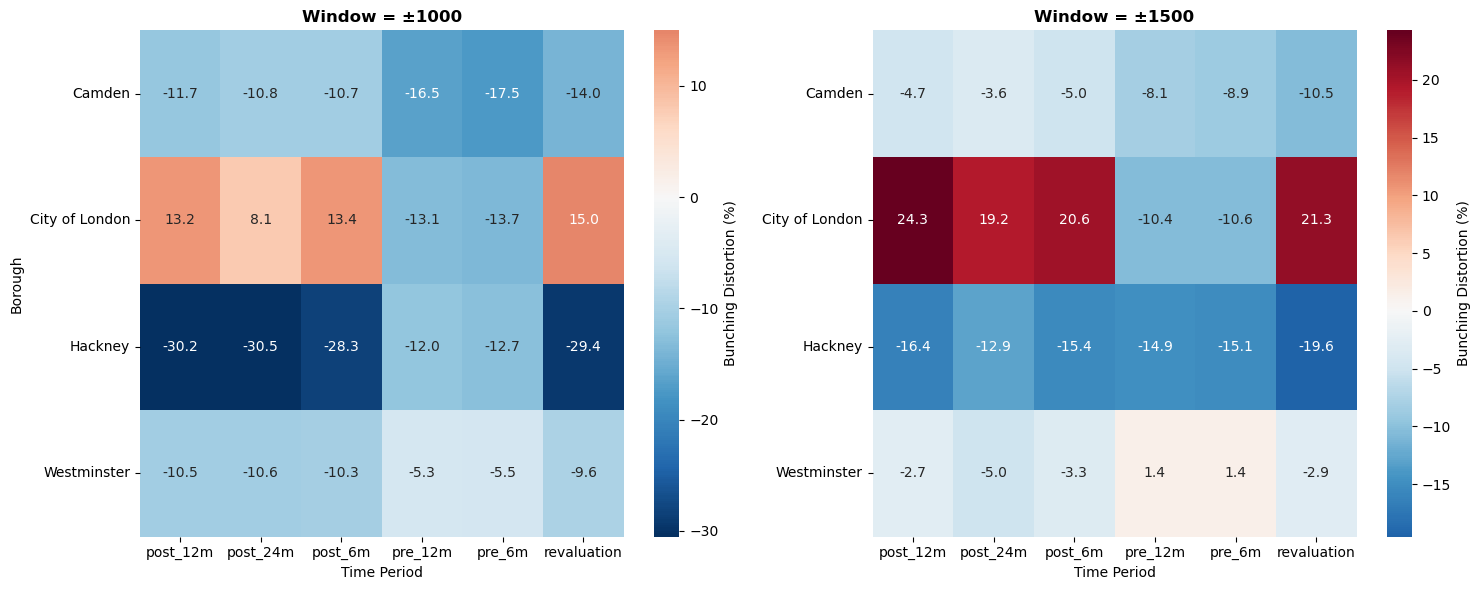

In [139]:
comparison_results = quick_bunching_comparison(data_2017)